# Notebook-first application walkthrough

**Problem / objective:** Identify customers at meaningful churn risk while avoiding a retention campaign that spends money on everyone.

**Decision / solution:** Use calibrated probabilities and retention economics to decide who should receive an intervention and where manual review is justified.

This front section is intentionally analysis-first. It uses direct notebook code for inspection, EDA, visualisation and evidence review. The original notebook work is preserved below, followed by modular production code where that adds engineering evidence.


In [ ]:
from pathlib import Path
import json
import os
import subprocess
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings('ignore')
PROJECT_SLUG = 'customer_churn_prediction'
ROOT = Path.cwd()
if not (ROOT / 'projects').exists():
    candidate = ROOT.parent.parent if ROOT.name == PROJECT_SLUG else ROOT
    if (candidate / 'projects').exists():
        ROOT = candidate
PROJECT = ROOT / 'projects' / PROJECT_SLUG
if not PROJECT.exists() and Path.cwd().name == PROJECT_SLUG:
    PROJECT = Path.cwd()
    ROOT = PROJECT.parent.parent
assert PROJECT.exists(), f'Project directory not found: {PROJECT}'
print('Repository root:', ROOT.resolve())
print('Project:', PROJECT.resolve())


## 1. Find the real data and retained evidence

Instead of hiding the dataset behind a helper function, start by seeing what the project actually ships: raw/small data, fixtures, outputs, results and verified evidence. External large datasets remain reproducibly downloadable from the documented source.


In [ ]:
candidate_files = []
for pattern in ('*.csv', '*.parquet', '*.json', '*.tsv', '*.txt'):
    candidate_files.extend(PROJECT.rglob(pattern))
verified_dir = ROOT / 'verified' / PROJECT_SLUG
if verified_dir.exists():
    for pattern in ('*.csv', '*.parquet', '*.json', '*.tsv', '*.txt'):
        candidate_files.extend(verified_dir.rglob(pattern))
candidate_files = sorted({p.resolve() for p in candidate_files if p.is_file()})
file_inventory = pd.DataFrame({
    'file': [str(p.relative_to(ROOT)) if ROOT in p.parents else str(p) for p in candidate_files],
    'suffix': [p.suffix.lower() for p in candidate_files],
    'size_kb': [round(p.stat().st_size / 1024, 1) for p in candidate_files],
})
display(file_inventory.head(40))
print(f'Inspectable local data/evidence files: {len(file_inventory):,}')


## 2. Direct tabular data audit

The code below deliberately avoids a project-specific wrapper. It opens the first sensible local tabular asset, shows its schema and quality profile, and makes the data issues visible before modelling. If the full raw dataset is external, run the project's documented download cell/entry point first and rerun this section.


In [ ]:
tabular_candidates = [p for p in candidate_files if p.suffix.lower() in {'.csv', '.tsv', '.parquet'}]
preferred = [p for p in tabular_candidates if not any(token in p.name.lower() for token in ('metric', 'summary', 'verification'))]
tabular_path = (preferred or tabular_candidates or [None])[0]
df = None
if tabular_path is not None:
    if tabular_path.suffix.lower() == '.parquet':
        df = pd.read_parquet(tabular_path)
    else:
        sep = '\t' if tabular_path.suffix.lower() == '.tsv' else ','
        df = pd.read_csv(tabular_path, sep=sep, nrows=200_000)
    print('Loaded:', tabular_path)
    print('Shape:', df.shape)
    display(df.head())
    audit = pd.DataFrame({
        'dtype': df.dtypes.astype(str),
        'missing': df.isna().sum(),
        'missing_pct': (100 * df.isna().mean()).round(2),
        'unique': df.nunique(dropna=False),
    }).sort_values(['missing_pct', 'unique'], ascending=[False, False])
    display(audit.head(30))
    print('Duplicate rows:', int(df.duplicated().sum()))
else:
    print('No local CSV/TSV/Parquet found yet. Use the project README/run path to download or build the documented dataset, then rerun this audit.')


## 3. Exploratory data analysis and visualisation

These plots are intentionally created in the notebook rather than described in prose. They expose distribution, missingness, scale, category balance and numeric relationships before any final model decision.


In [ ]:
if df is not None and len(df):
    missing_pct = (100 * df.isna().mean()).sort_values(ascending=False).head(20)
    missing_pct = missing_pct[missing_pct > 0]
    if len(missing_pct):
        plt.figure(figsize=(10, 4))
        missing_pct.plot(kind='bar')
        plt.title('Missing values by feature (%)')
        plt.ylabel('Missing %')
        plt.xticks(rotation=60, ha='right')
        plt.tight_layout()
        plt.show()

    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()[:8]
    for col in numeric_cols:
        series = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(series):
            plt.figure(figsize=(8, 4))
            plt.hist(series, bins=30, alpha=0.8)
            plt.axvline(series.median(), linestyle='--', label=f'median={series.median():.2f}')
            plt.title(f'Distribution: {col}')
            plt.xlabel(col)
            plt.ylabel('Count')
            plt.legend()
            plt.tight_layout()
            plt.show()

    categorical_cols = [c for c in df.columns if c not in numeric_cols and df[c].nunique(dropna=False) <= 30][:4]
    for col in categorical_cols:
        counts = df[col].fillna('<missing>').astype(str).value_counts().head(15)
        plt.figure(figsize=(9, 4))
        counts.sort_values().plot(kind='barh')
        plt.title(f'Top categories: {col}')
        plt.xlabel('Rows')
        plt.tight_layout()
        plt.show()

    if len(numeric_cols) >= 2:
        corr = df[numeric_cols].corr(numeric_only=True)
        plt.figure(figsize=(8, 6))
        image = plt.imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
        plt.colorbar(image, label='Correlation')
        plt.xticks(range(len(corr.columns)), corr.columns, rotation=60, ha='right')
        plt.yticks(range(len(corr.index)), corr.index)
        plt.title('Numeric correlation matrix')
        plt.tight_layout()
        plt.show()

    if len(numeric_cols) >= 2:
        x_col, y_col = numeric_cols[0], numeric_cols[-1]
        sample = df[[x_col, y_col]].dropna().sample(min(3000, len(df.dropna(subset=[x_col, y_col]))), random_state=42)
        if len(sample):
            plt.figure(figsize=(7, 5))
            plt.scatter(sample[x_col], sample[y_col], alpha=0.35, s=18)
            plt.xlabel(x_col)
            plt.ylabel(y_col)
            plt.title(f'{y_col} versus {x_col}')
            plt.tight_layout()
            plt.show()
else:
    print('Run the documented data-build/download path, then rerun this section to render raw-data EDA.')


## 4. Inspect the measured results, not just the code

A portfolio project is stronger when it retains evidence. This section reads machine-readable JSON/CSV outputs and turns scalar metrics into a quick visual comparison.


In [ ]:
json_files = [p for p in candidate_files if p.suffix.lower() == '.json']
metric_rows = []
for path in json_files[:30]:
    try:
        payload = json.loads(path.read_text(encoding='utf-8'))
    except Exception:
        continue
    stack = [('', payload)]
    while stack:
        prefix, value = stack.pop()
        if isinstance(value, dict):
            for key, child in value.items():
                stack.append((f'{prefix}.{key}' if prefix else str(key), child))
        elif isinstance(value, (int, float)) and not isinstance(value, bool) and np.isfinite(value):
            metric_rows.append({
                'file': str(path.relative_to(ROOT)) if ROOT in path.parents else str(path),
                'metric': prefix,
                'value': float(value),
            })
metrics_df = pd.DataFrame(metric_rows)
if len(metrics_df):
    display(metrics_df.head(40))
    plot_df = metrics_df[np.isfinite(metrics_df['value'])].copy()
    plot_df = plot_df[plot_df['value'].abs() < 1_000_000].head(20)
    if len(plot_df):
        labels = (plot_df['file'].str.split('/').str[-1] + ' :: ' + plot_df['metric']).tolist()
        plt.figure(figsize=(10, max(4, 0.35 * len(plot_df))))
        plt.barh(range(len(plot_df)), plot_df['value'])
        plt.yticks(range(len(plot_df)), labels)
        plt.title('Retained project metrics / evidence')
        plt.tight_layout()
        plt.show()
else:
    print('No scalar JSON evidence found. Run the project and retain metrics/results before treating it as complete.')


## 5. Reproduce the application

The notebook should be understandable without running anything, but a reviewer can reproduce the canonical application below. The switch is off by default so opening the notebook never triggers a long training job unexpectedly.


In [ ]:
RUN_PROJECT = False
entrypoint = PROJECT / 'run.py'
if RUN_PROJECT and entrypoint.exists():
    subprocess.run([sys.executable, str(entrypoint)], cwd=PROJECT, check=True)
elif entrypoint.exists():
    print(f'Reproduce with: cd {PROJECT} && {sys.executable} run.py')
else:
    print('This project uses a different documented entry point; see README.md in the project folder.')


## 6. Decision / solution

Use calibrated probabilities and retention economics to decide who should receive an intervention and where manual review is justified.

The final recommendation should be tied to the measured validation evidence and error analysis below. A model is not the solution by itself; the solution is the decision process built around it.


# Project 03 — Customer Churn Prediction

**Author:** Jorgo Luka  
**Format:** Standalone Google Colab notebook  
**Dataset:** UCI Iranian Churn — 3,150 telecom customers observed over 12 months  
**Core tools:** Python · Pandas · scikit-learn · Matplotlib · Seaborn

## Recruiter summary

This project builds a decision-ready churn screening system rather than an accuracy-only classifier. It protects the holdout set, isolates duplicate customer profiles between splits, compares a prevalence baseline with interpretable and nonlinear models, calibrates probabilities from grouped out-of-fold predictions and selects an intervention threshold using explicit decision costs.

| Capability | Evidence |
|---|---|
| Problem design | Nine-month feature window, three-month planning gap and end-of-year churn outcome |
| Leakage control | Duplicate-profile grouping, untouched holdout, age exclusion and `Status` proxy sensitivity test |
| Modelling | Dummy baseline, logistic regression, random forest and histogram gradient boosting |
| Evaluation | PR-AUC, ROC-AUC, Brier score, calibration, bootstrap intervals and failure slices |
| Decision layer | Cost-based threshold, capacity/alert rate, subgroup review and validated inference function |
| Engineering | Data/model cards, serialized model bundle, drift reference, tests and SHA-256 manifest |

> This is a screening model for prioritising retention review. It does not prove why a customer churned and must not trigger adverse treatment automatically.

## Business question and decision

**Question:** Which customers should a retention team review during a three-month planning window?

**Decision:** Flag customers when their calibrated churn probability exceeds a threshold chosen on training-only out-of-fold predictions.

**Primary model-selection metric:** average precision (PR-AUC), because only about one customer in six churns and accuracy can hide missed churners.

**Decision-cost assumptions:**

- Contacting or reviewing a flagged customer: 25 cost units.
- Missing a customer who later churns: 200 cost units.
- Correctly leaving a non-churner unflagged: 0 cost units.

These are transparent scenario weights, not claimed company currency or realised savings. A production owner should replace them with measured intervention costs and incremental retention value from an experiment.

## Data source, chronology and licence

- Dataset: [Iranian Churn, UCI Machine Learning Repository](https://archive.ics.uci.edu/dataset/563/iranian+churn+dataset)
- DOI: [10.24432/C5JW3Z](https://doi.org/10.24432/C5JW3Z)
- Licence: [CC BY 4.0](https://creativecommons.org/licenses/by/4.0/)

UCI states that the records were randomly collected from an Iranian telecom company's database over 12 months. Predictors summarize the first nine months; churn is measured at the end of month 12, leaving a three-month planning gap. The file contains no customer identifier or event timestamps, so the notebook uses grouped stratified validation rather than pretending it can perform a true calendar-time split.

## 0. Environment and reproducibility

Run **Runtime → Restart session and run all** in Google Colab. No private account or API key is required.

In [1]:
%pip -q install "scikit-learn>=1.5,<1.9" "joblib>=1.3" "gradio>=5,<7"

In [2]:
from __future__ import annotations

import datetime as dt
import hashlib
import json
import math
import platform
import random
import re
import urllib.request
import zipfile
from dataclasses import asdict, dataclass
from pathlib import Path
from typing import Any

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
from scipy.special import expit, logit
from sklearn.base import clone
from sklearn.calibration import calibration_curve
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import HistGradientBoostingClassifier, RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    log_loss,
    make_scorer,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import RobustScaler

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")


@dataclass(frozen=True)
class ProjectConfig:
    dataset_url: str = "https://archive.ics.uci.edu/static/public/563/iranian+churn+dataset.zip"
    archive_name: str = "iranian_churn_dataset.zip"
    csv_name: str = "Customer Churn.csv"
    artifact_dir: str = "customer_churn_artifacts"
    holdout_folds: int = 5
    cross_validation_folds: int = 5
    contact_cost_units: float = 25.0
    missed_churn_cost_units: float = 200.0
    bootstrap_repetitions: int = 500
    permutation_repetitions: int = 20
    parallel_jobs: int = 1
    launch_app: bool = False


CFG = ProjectConfig()
DATA_DIR = Path("churn_source_data")
ARTIFACTS = Path(CFG.artifact_dir)
DATA_DIR.mkdir(exist_ok=True)
ARTIFACTS.mkdir(exist_ok=True)

print({
    "python": platform.python_version(),
    "pandas": pd.__version__,
    "scikit_learn": sklearn.__version__,
    "configuration": asdict(CFG),
})

{'python': '3.12.13', 'pandas': '2.2.3', 'scikit_learn': '1.8.0', 'configuration': {'dataset_url': 'https://archive.ics.uci.edu/static/public/563/iranian+churn+dataset.zip', 'archive_name': 'iranian_churn_dataset.zip', 'csv_name': 'Customer Churn.csv', 'artifact_dir': 'customer_churn_artifacts', 'holdout_folds': 5, 'cross_validation_folds': 5, 'contact_cost_units': 25.0, 'missed_churn_cost_units': 200.0, 'bootstrap_repetitions': 500, 'permutation_repetitions': 20, 'parallel_jobs': 1, 'launch_app': False}}


## 1. Download and fingerprint the source

The notebook downloads the version-pinned UCI archive directly. Both the ZIP archive and extracted CSV must match their expected SHA-256 digests before any analysis can run, preventing a silent source revision from changing the reported evidence.


In [3]:
REFERENCE_ARCHIVE_SHA256 = "696c3a1812267980751f30d19193a1b430ac4ad76172bb089e664c96813ead66"
REFERENCE_CSV_SHA256 = "90d5fb6bd1630cd4de4b4d28fcf8b4cb92a8f6ab7484605b0799d47386f7dbe1"
ARCHIVE_PATH = DATA_DIR / CFG.archive_name
CSV_PATH = DATA_DIR / CFG.csv_name


def sha256_file(path: Path, chunk_size: int = 1 << 20) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        while chunk := handle.read(chunk_size):
            digest.update(chunk)
    return digest.hexdigest()


if not ARCHIVE_PATH.exists():
    request = urllib.request.Request(CFG.dataset_url, headers={"User-Agent": "Mozilla/5.0"})
    temporary_path = ARCHIVE_PATH.with_suffix(".zip.part")
    try:
        with urllib.request.urlopen(request, timeout=120) as response, temporary_path.open("wb") as target:
            while chunk := response.read(1 << 20):
                target.write(chunk)
        temporary_path.replace(ARCHIVE_PATH)
    finally:
        temporary_path.unlink(missing_ok=True)

archive_sha256 = sha256_file(ARCHIVE_PATH)
assert archive_sha256 == REFERENCE_ARCHIVE_SHA256, (
    "The UCI archive does not match the pinned source. Review it before using any result."
)

with zipfile.ZipFile(ARCHIVE_PATH) as archive:
    assert CFG.csv_name in archive.namelist(), f"Expected {CFG.csv_name} in source archive"
    archive.extract(CFG.csv_name, DATA_DIR)

csv_sha256 = sha256_file(CSV_PATH)
assert csv_sha256 == REFERENCE_CSV_SHA256, (
    "The extracted CSV does not match the pinned source. Review it before using any result."
)

SOURCE_FINGERPRINT = {
    "dataset": "UCI Iranian Churn",
    "source_url": CFG.dataset_url,
    "doi": "10.24432/C5JW3Z",
    "archive_bytes": ARCHIVE_PATH.stat().st_size,
    "archive_sha256": archive_sha256,
    "csv_bytes": CSV_PATH.stat().st_size,
    "csv_sha256": csv_sha256,
    "matches_reference_archive": archive_sha256 == REFERENCE_ARCHIVE_SHA256,
    "matches_reference_csv": csv_sha256 == REFERENCE_CSV_SHA256,
    "retrieved_utc": dt.datetime.now(dt.timezone.utc).isoformat(),
}
print(json.dumps(SOURCE_FINGERPRINT, indent=2))
print("Archive and extracted CSV passed SHA-256 verification.")


{
  "dataset": "UCI Iranian Churn",
  "source_url": "https://archive.ics.uci.edu/static/public/563/iranian+churn+dataset.zip",
  "doi": "10.24432/C5JW3Z",
  "archive_bytes": 41943,
  "archive_sha256": "696c3a1812267980751f30d19193a1b430ac4ad76172bb089e664c96813ead66",
  "csv_bytes": 131728,
  "csv_sha256": "90d5fb6bd1630cd4de4b4d28fcf8b4cb92a8f6ab7484605b0799d47386f7dbe1",
  "matches_reference_archive": true,
  "matches_reference_csv": true,
  "retrieved_utc": "2026-08-11T21:50:58.039465+00:00"
}
Archive and extracted CSV passed SHA-256 verification.


## 2. Load, normalise and validate the data contract

Column names contain inconsistent double spaces in the source. Names are normalised deterministically; values are not edited or imputed because the pinned file has no missing entries.

In [4]:
def normalise_column(name: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", name.strip().lower()).strip("_")


raw = pd.read_csv(CSV_PATH)
raw.columns = [normalise_column(column) for column in raw.columns]

EXPECTED_COLUMNS = [
    "call_failure",
    "complains",
    "subscription_length",
    "charge_amount",
    "seconds_of_use",
    "frequency_of_use",
    "frequency_of_sms",
    "distinct_called_numbers",
    "age_group",
    "tariff_plan",
    "status",
    "age",
    "customer_value",
    "churn",
]

assert raw.columns.tolist() == EXPECTED_COLUMNS

DATA_CONTRACT = pd.DataFrame([
    {"field": "churn", "role": "target", "allowed": "0 or 1", "timing": "end of month 12"},
    {"field": "complains", "role": "binary feature", "allowed": "0 or 1", "timing": "first 9 months"},
    {"field": "tariff_plan", "role": "service feature", "allowed": "1 or 2", "timing": "first 9 months"},
    {"field": "status", "role": "proxy-risk feature", "allowed": "1 or 2", "timing": "first 9 months"},
    {"field": "age_group", "role": "audit only", "allowed": "1 through 5", "timing": "customer attribute"},
    {"field": "age", "role": "audit only", "allowed": "non-negative", "timing": "customer attribute"},
    {"field": "remaining numeric fields", "role": "model features", "allowed": "non-negative", "timing": "first 9 months"},
])

quality_profile = pd.DataFrame({
    "dtype": raw.dtypes.astype(str),
    "missing": raw.isna().sum(),
    "unique": raw.nunique(),
    "minimum": raw.min(numeric_only=True),
    "maximum": raw.max(numeric_only=True),
}).reset_index(names="field")

assert raw.shape == (3150, 14)
assert raw.isna().sum().sum() == 0
assert set(raw["churn"].unique()) == {0, 1}
assert set(raw["complains"].unique()).issubset({0, 1})
assert set(raw["tariff_plan"].unique()).issubset({1, 2})
assert set(raw["status"].unique()).issubset({1, 2})
assert set(raw["age_group"].unique()).issubset({1, 2, 3, 4, 5})
assert (raw.drop(columns="churn") >= 0).all().all()

display(DATA_CONTRACT)
display(quality_profile)
print(f"Raw shape: {raw.shape[0]:,} customers × {raw.shape[1]} columns")

Raw shape: 3,150 customers × 14 columns


,field,role,allowed,timing
0,churn,target,0 or 1,end of month 12
1,complains,binary feature,0 or 1,first 9 months
2,tariff_plan,service feature,1 or 2,first 9 months
3,status,proxy-risk feature,1 or 2,first 9 months
4,age_group,audit only,1 through 5,customer attribute
5,age,audit only,non-negative,customer attribute
6,remaining numeric fields,model features,non-negative,first 9 months


,field,dtype,missing,unique,minimum,maximum
0,call_failure,int64,0,37,0.0000,36.0000
1,complains,int64,0,2,0.0000,1.0000
2,subscription_length,int64,0,45,3.0000,47.0000
3,charge_amount,int64,0,11,0.0000,10.0000
4,seconds_of_use,int64,0,1756,0.0000,"17,090.0000"
5,frequency_of_use,int64,0,242,0.0000,255.0000
6,frequency_of_sms,int64,0,405,0.0000,522.0000
7,distinct_called_numbers,int64,0,92,0.0000,97.0000
8,age_group,int64,0,5,1.0000,5.0000
9,tariff_plan,int64,0,2,1.0000,2.0000


## 3. Duplicate-profile audit and leakage-safe grouping

The file has no customer ID. Exact duplicate rows could be repeated customers, different customers with the same aggregate profile or source duplication. Deleting them would invent an unsupported assumption. Randomly splitting them could place identical profiles in training and testing, making generalisation look better than it is.

This notebook therefore keeps every row but assigns identical predictor profiles to the same validation group. Even profiles with conflicting churn outcomes remain together.

In [5]:
X_raw = raw.drop(columns="churn").copy()
y = raw["churn"].astype(int).copy()

OPERATIONAL_INPUT_COLUMNS = [
    "call_failure",
    "complains",
    "subscription_length",
    "charge_amount",
    "seconds_of_use",
    "frequency_of_use",
    "frequency_of_sms",
    "distinct_called_numbers",
    "tariff_plan",
    "customer_value",
]
operational_profiles = X_raw[OPERATIONAL_INPUT_COLUMNS]

full_duplicate_rows = int(raw.duplicated().sum())
feature_duplicate_rows = int(operational_profiles.duplicated().sum())
profile_groups = pd.util.hash_pandas_object(operational_profiles, index=False).astype(str)

profile_audit = (
    raw.groupby(OPERATIONAL_INPUT_COLUMNS, dropna=False)["churn"]
    .agg(rows="size", target_classes="nunique", churn_rate="mean")
    .reset_index()
)
mixed_label_profiles = int((profile_audit["target_classes"] > 1).sum())
rows_in_mixed_profiles = int(profile_audit.loc[profile_audit["target_classes"] > 1, "rows"].sum())

DUPLICATE_AUDIT = {
    "exact_duplicate_rows_including_target": full_duplicate_rows,
    "duplicate_operational_profile_rows": feature_duplicate_rows,
    "unique_operational_profiles": int(profile_groups.nunique()),
    "mixed_label_profiles": mixed_label_profiles,
    "rows_in_mixed_label_profiles": rows_in_mixed_profiles,
    "handling": "retain all rows; keep identical predictor profiles in one split group",
}
print(json.dumps(DUPLICATE_AUDIT, indent=2))

{
  "exact_duplicate_rows_including_target": 300,
  "duplicate_operational_profile_rows": 356,
  "unique_operational_profiles": 2794,
  "mixed_label_profiles": 15,
  "rows_in_mixed_label_profiles": 107,
  "handling": "retain all rows; keep identical predictor profiles in one split group"
}


## 4. Exploratory analysis

Charts are descriptive and use the full dataset before modelling. They do not select a test threshold or tune a model.

,outcome,customers,share_pct
0,Retained,2655,84.2857
1,Churned,495,15.7143


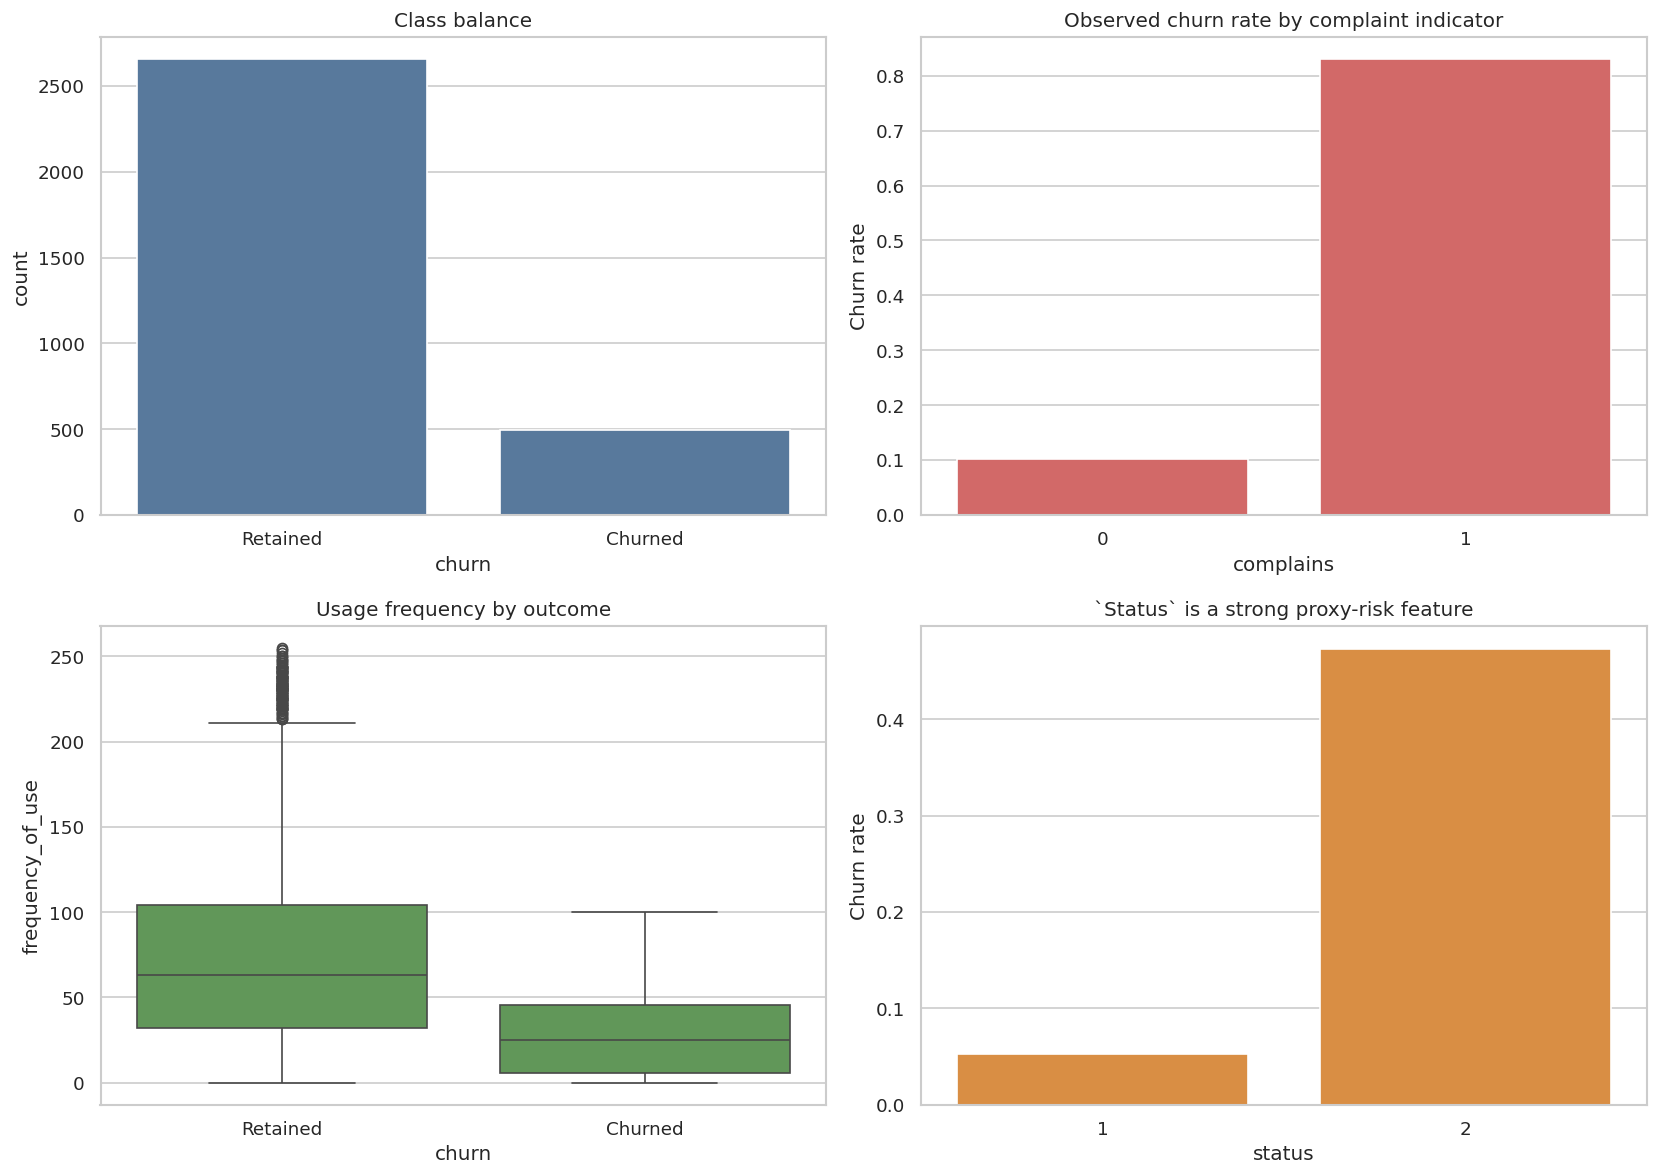

In [6]:
class_balance = (
    raw["churn"].value_counts().rename(index={0: "Retained", 1: "Churned"})
    .rename_axis("outcome").reset_index(name="customers")
)
class_balance["share_pct"] = 100 * class_balance["customers"] / len(raw)
display(class_balance)

churn_by_complaint = (
    raw.groupby("complains")["churn"].agg(customers="size", churn_rate="mean").reset_index()
)
churn_by_status = (
    raw.groupby("status")["churn"].agg(customers="size", churn_rate="mean").reset_index()
)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.countplot(data=raw, x="churn", ax=axes[0, 0], color="#4C78A8")
axes[0, 0].set_title("Class balance")
axes[0, 0].set_xticks([0, 1], labels=["Retained", "Churned"])
sns.barplot(data=churn_by_complaint, x="complains", y="churn_rate", ax=axes[0, 1], color="#E45756")
axes[0, 1].set_title("Observed churn rate by complaint indicator")
axes[0, 1].set_ylabel("Churn rate")
sns.boxplot(data=raw, x="churn", y="frequency_of_use", ax=axes[1, 0], color="#59A14F")
axes[1, 0].set_title("Usage frequency by outcome")
axes[1, 0].set_xticks([0, 1], labels=["Retained", "Churned"])
sns.barplot(data=churn_by_status, x="status", y="churn_rate", ax=axes[1, 1], color="#F28E2B")
axes[1, 1].set_title("`Status` is a strong proxy-risk feature")
axes[1, 1].set_ylabel("Churn rate")
plt.tight_layout()
eda_chart_path = ARTIFACTS / "data_overview.png"
plt.savefig(eda_chart_path, dpi=160, bbox_inches="tight")
plt.show()

## 5. Protected holdout split

One fold is reserved as the final holdout and is not used for model selection, calibration fitting or threshold selection. `StratifiedGroupKFold` approximately preserves churn prevalence while preventing identical predictor profiles from crossing the boundary.

In [7]:
holdout_splitter = StratifiedGroupKFold(
    n_splits=CFG.holdout_folds,
    shuffle=True,
    random_state=SEED,
)
train_index, test_index = next(holdout_splitter.split(X_raw, y, groups=profile_groups))

raw_train = X_raw.iloc[train_index].reset_index(drop=True)
raw_test = X_raw.iloc[test_index].reset_index(drop=True)
y_train = y.iloc[train_index].reset_index(drop=True)
y_test = y.iloc[test_index].reset_index(drop=True)
groups_train = profile_groups.iloc[train_index].reset_index(drop=True)
groups_test = profile_groups.iloc[test_index].reset_index(drop=True)

split_profile = pd.DataFrame([
    {
        "split": "training",
        "rows": len(raw_train),
        "predictor_profiles": groups_train.nunique(),
        "churners": int(y_train.sum()),
        "churn_rate": y_train.mean(),
    },
    {
        "split": "holdout",
        "rows": len(raw_test),
        "predictor_profiles": groups_test.nunique(),
        "churners": int(y_test.sum()),
        "churn_rate": y_test.mean(),
    },
])

group_overlap = len(set(groups_train).intersection(set(groups_test)))
assert group_overlap == 0
display(split_profile)
print(f"Duplicate-profile group overlap: {group_overlap}")

Duplicate-profile group overlap: 0


,split,rows,predictor_profiles,churners,churn_rate
0,training,2522,2229,397,0.1574
1,holdout,628,565,98,0.1561


## 6. Feature policy and engineering

Two fields are excluded from the operational model:

- `age` and `age_group`: retained only for subgroup monitoring, avoiding age-based retention targeting.
- `status`: semantically close to active/non-active state and therefore tested as a potentially over-powerful proxy. The deployment candidate excludes it even if it improves prediction.

All engineered ratios use only first-nine-month measurements and fixed arithmetic; no full-dataset statistics are learned.

In [8]:
MODEL_INPUT_COLUMNS = OPERATIONAL_INPUT_COLUMNS.copy()


def engineer_features(frame: pd.DataFrame, include_status: bool = False) -> pd.DataFrame:
    data = frame.copy()
    data = data.drop(columns=["age", "age_group"], errors="ignore")
    if not include_status:
        data = data.drop(columns=["status"], errors="ignore")

    call_denominator = data["frequency_of_use"].clip(lower=0) + 1.0
    subscription_denominator = data["subscription_length"].clip(lower=1)
    data["call_failure_rate"] = (
        data["call_failure"] / (data["call_failure"] + data["frequency_of_use"] + 1.0)
    )
    data["seconds_per_call"] = data["seconds_of_use"] / call_denominator
    data["sms_per_call"] = data["frequency_of_sms"] / call_denominator
    data["contact_diversity"] = data["distinct_called_numbers"] / call_denominator
    data["customer_value_per_month"] = data["customer_value"] / subscription_denominator
    data["usage_per_month"] = data["frequency_of_use"] / subscription_denominator
    return data.astype(float)


X_train = engineer_features(raw_train, include_status=False)
X_test = engineer_features(raw_test, include_status=False)
X_train_with_status = engineer_features(raw_train, include_status=True)

assert "status" not in X_train.columns
assert "age" not in X_train.columns and "age_group" not in X_train.columns
assert X_train.columns.tolist() == X_test.columns.tolist()
assert np.isfinite(X_train.to_numpy()).all()

feature_policy = pd.DataFrame({
    "feature": raw_train.columns,
    "operational_model": [column in MODEL_INPUT_COLUMNS for column in raw_train.columns],
    "reason_if_excluded": [
        "proxy sensitivity only" if column == "status"
        else "subgroup monitoring only" if column in {"age", "age_group"}
        else "included"
        for column in raw_train.columns
    ],
})
display(feature_policy)
print(f"Engineered model matrix: {X_train.shape[0]:,} rows × {X_train.shape[1]} features")

Engineered model matrix: 2,522 rows × 16 features


,feature,operational_model,reason_if_excluded
0,call_failure,True,included
1,complains,True,included
2,subscription_length,True,included
3,charge_amount,True,included
4,seconds_of_use,True,included
5,frequency_of_use,True,included
6,frequency_of_sms,True,included
7,distinct_called_numbers,True,included
8,age_group,False,subgroup monitoring only
9,tariff_plan,True,included


## 7. Baseline-first grouped cross-validation

Fixed, reviewable configurations are compared on the training split. Average precision is the primary selection metric; ROC-AUC, balanced accuracy, recall, precision and Brier score provide complementary views.

,model,mean_average_precision,sd_average_precision,mean_roc_auc,mean_balanced_accuracy,mean_recall_at_0_5,mean_precision_at_0_5,mean_brier_score
0,Histogram gradient boosting,0.9042,0.0576,0.9787,0.9231,0.8953,0.7853,0.0441
1,Random forest,0.8626,0.0836,0.9738,0.8919,0.8319,0.7786,0.0499
2,Logistic regression,0.7288,0.0452,0.9221,0.8380,0.8672,0.4608,0.1179
3,Prevalence baseline,0.1574,0.0021,0.5000,0.5000,0.0000,0.0000,0.1326


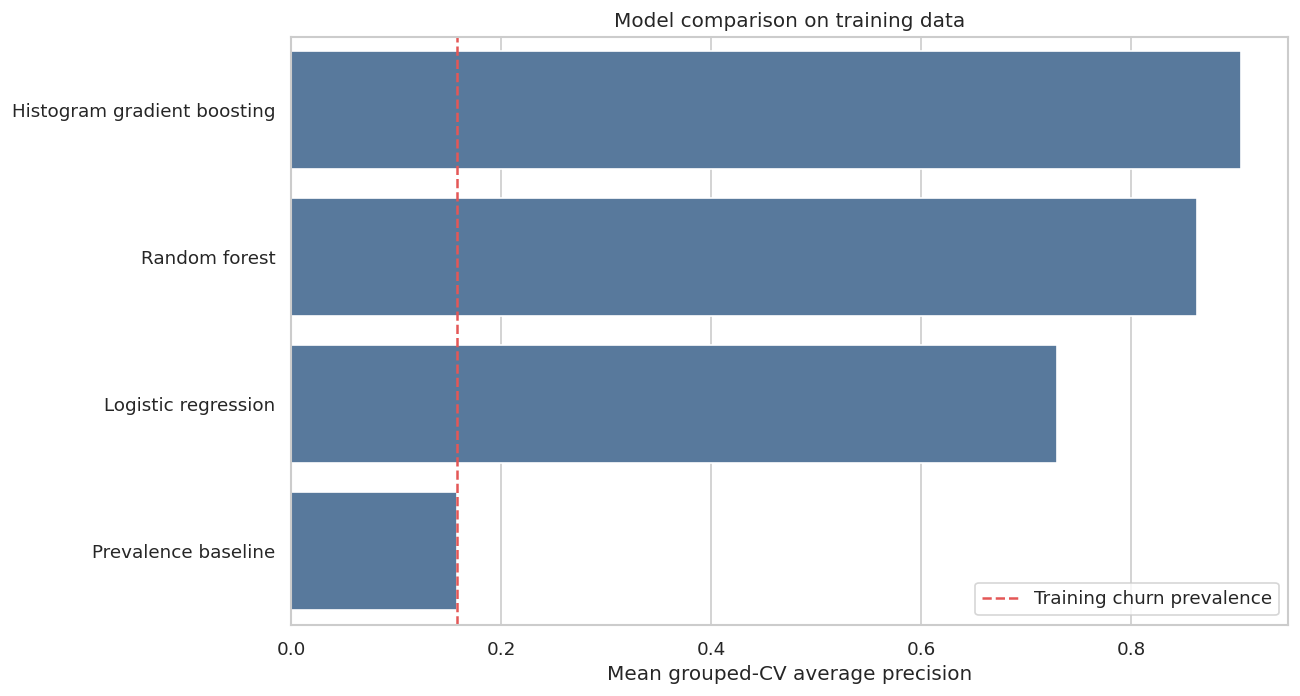

In [9]:
precision_scorer = make_scorer(precision_score, zero_division=0)
SCORING = {
    "average_precision": "average_precision",
    "roc_auc": "roc_auc",
    "balanced_accuracy": "balanced_accuracy",
    "recall": "recall",
    "precision": precision_scorer,
    "neg_brier": "neg_brier_score",
}

CANDIDATES = {
    "Prevalence baseline": DummyClassifier(strategy="prior"),
    "Logistic regression": Pipeline([
        ("scale", RobustScaler()),
        ("model", LogisticRegression(max_iter=3000, class_weight="balanced", random_state=SEED)),
    ]),
    "Random forest": RandomForestClassifier(
        n_estimators=500,
        min_samples_leaf=3,
        max_features="sqrt",
        class_weight="balanced_subsample",
        random_state=SEED,
        n_jobs=CFG.parallel_jobs,
    ),
    "Histogram gradient boosting": HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        min_samples_leaf=20,
        l2_regularization=1.0,
        class_weight="balanced",
        random_state=SEED,
    ),
}

cv_splitter = StratifiedGroupKFold(
    n_splits=CFG.cross_validation_folds,
    shuffle=True,
    random_state=2026,
)

cv_rows = []
for model_name, estimator in CANDIDATES.items():
    scores = cross_validate(
        estimator,
        X_train,
        y_train,
        groups=groups_train,
        cv=cv_splitter,
        scoring=SCORING,
        n_jobs=CFG.parallel_jobs,
        return_train_score=False,
    )
    for fold in range(CFG.cross_validation_folds):
        cv_rows.append({
            "model": model_name,
            "fold": fold + 1,
            "average_precision": scores["test_average_precision"][fold],
            "roc_auc": scores["test_roc_auc"][fold],
            "balanced_accuracy": scores["test_balanced_accuracy"][fold],
            "recall_at_0_5": scores["test_recall"][fold],
            "precision_at_0_5": scores["test_precision"][fold],
            "brier_score": -scores["test_neg_brier"][fold],
        })

cv_results = pd.DataFrame(cv_rows)
cv_summary = (
    cv_results.groupby("model")
    .agg(
        mean_average_precision=("average_precision", "mean"),
        sd_average_precision=("average_precision", "std"),
        mean_roc_auc=("roc_auc", "mean"),
        mean_balanced_accuracy=("balanced_accuracy", "mean"),
        mean_recall_at_0_5=("recall_at_0_5", "mean"),
        mean_precision_at_0_5=("precision_at_0_5", "mean"),
        mean_brier_score=("brier_score", "mean"),
    )
    .sort_values("mean_average_precision", ascending=False)
    .reset_index()
)
display(cv_summary)

plt.figure(figsize=(11, 6))
sns.barplot(data=cv_summary, y="model", x="mean_average_precision", color="#4C78A8")
plt.axvline(y_train.mean(), color="#E45756", linestyle="--", label="Training churn prevalence")
plt.xlabel("Mean grouped-CV average precision")
plt.ylabel("")
plt.title("Model comparison on training data")
plt.legend()
plt.tight_layout()
model_comparison_chart_path = ARTIFACTS / "model_comparison.png"
plt.savefig(model_comparison_chart_path, dpi=160, bbox_inches="tight")
plt.show()

## 8. Select the model and audit `Status`

The best non-baseline model is selected using training-only grouped-CV average precision. The same algorithm is then evaluated with and without `Status`. This is a sensitivity analysis, not permission to deploy the proxy.

In [10]:
eligible_models = cv_summary.loc[cv_summary["model"] != "Prevalence baseline"]
selected_model_name = str(eligible_models.iloc[0]["model"])
selected_estimator_template = CANDIDATES[selected_model_name]

status_sensitivity_rows = []
for feature_policy_name, feature_matrix in {
    "Status excluded": X_train,
    "Status included": X_train_with_status,
}.items():
    scores = cross_validate(
        clone(selected_estimator_template),
        feature_matrix,
        y_train,
        groups=groups_train,
        cv=cv_splitter,
        scoring={"average_precision": "average_precision", "roc_auc": "roc_auc", "brier": "neg_brier_score"},
        n_jobs=CFG.parallel_jobs,
    )
    status_sensitivity_rows.append({
        "feature_policy": feature_policy_name,
        "mean_average_precision": scores["test_average_precision"].mean(),
        "mean_roc_auc": scores["test_roc_auc"].mean(),
        "mean_brier_score": -scores["test_brier"].mean(),
    })

status_sensitivity = pd.DataFrame(status_sensitivity_rows)
status_ap_lift = float(
    status_sensitivity.set_index("feature_policy").loc["Status included", "mean_average_precision"]
    - status_sensitivity.set_index("feature_policy").loc["Status excluded", "mean_average_precision"]
)

display(status_sensitivity)
print(f"Selected algorithm: {selected_model_name}")
print(f"Average-precision lift from Status: {status_ap_lift:+.4f}")
print("Deployment policy: Status remains excluded because of semantic proxy risk.")

Selected algorithm: Histogram gradient boosting
Average-precision lift from Status: +0.0219
Deployment policy: Status remains excluded because of semantic proxy risk.


,feature_policy,mean_average_precision,mean_roc_auc,mean_brier_score
0,Status excluded,0.9042,0.9787,0.0441
1,Status included,0.9261,0.9833,0.0369


## 9. Cross-fitted probability calibration

Raw model scores are converted into probabilities with Platt scaling. First, grouped out-of-fold base-model predictions are generated so no row or duplicate profile is scored by a model that trained on it. A second grouped cross-fitting layer calibrates each row using a calibrator that did not fit that row's label. Those cross-fitted calibrated probabilities drive training diagnostics and threshold selection. The final deployment calibrator is then fitted on all out-of-fold scores, while the base model is fitted on all training rows.


In [11]:
def safe_logit(probabilities: np.ndarray) -> np.ndarray:
    clipped = np.clip(np.asarray(probabilities, dtype=float), 1e-6, 1 - 1e-6)
    return logit(clipped).reshape(-1, 1)


oof_raw_probability = cross_val_predict(
    clone(selected_estimator_template),
    X_train,
    y_train,
    groups=groups_train,
    cv=cv_splitter,
    method="predict_proba",
    n_jobs=CFG.parallel_jobs,
)[:, 1]

calibration_splitter = StratifiedGroupKFold(
    n_splits=CFG.cross_validation_folds,
    shuffle=True,
    random_state=2027,
)
oof_calibrated_probability = np.full(len(y_train), np.nan, dtype=float)

for calibration_train_index, calibration_validation_index in calibration_splitter.split(
    np.zeros((len(y_train), 1)), y_train, groups=groups_train
):
    fold_calibrator = LogisticRegression(C=1e6, max_iter=2000, random_state=SEED)
    fold_calibrator.fit(
        safe_logit(oof_raw_probability[calibration_train_index]),
        y_train.iloc[calibration_train_index],
    )
    oof_calibrated_probability[calibration_validation_index] = fold_calibrator.predict_proba(
        safe_logit(oof_raw_probability[calibration_validation_index])
    )[:, 1]

assert np.isfinite(oof_calibrated_probability).all()

probability_calibrator = LogisticRegression(C=1e6, max_iter=2000, random_state=SEED)
probability_calibrator.fit(safe_logit(oof_raw_probability), y_train)

final_base_model = clone(selected_estimator_template)
final_base_model.fit(X_train, y_train)


class PlattCalibratedModel:
    def __init__(self, base_model: Any, calibrator: Any):
        self.base_model = base_model
        self.calibrator = calibrator
        self.classes_ = np.array([0, 1])

    def predict_proba(self, features: pd.DataFrame) -> np.ndarray:
        raw_probability = self.base_model.predict_proba(features)[:, 1]
        calibrated = self.calibrator.predict_proba(safe_logit(raw_probability))[:, 1]
        return np.column_stack([1 - calibrated, calibrated])

    def predict(self, features: pd.DataFrame, threshold: float = 0.5) -> np.ndarray:
        return (self.predict_proba(features)[:, 1] >= threshold).astype(int)


calibrated_model = PlattCalibratedModel(final_base_model, probability_calibrator)

calibration_summary = pd.DataFrame([
    {
        "probabilities": "Raw grouped out-of-fold",
        "average_precision": average_precision_score(y_train, oof_raw_probability),
        "brier_score": brier_score_loss(y_train, oof_raw_probability),
        "log_loss": log_loss(y_train, oof_raw_probability),
    },
    {
        "probabilities": "Cross-fitted calibrated out-of-fold",
        "average_precision": average_precision_score(y_train, oof_calibrated_probability),
        "brier_score": brier_score_loss(y_train, oof_calibrated_probability),
        "log_loss": log_loss(y_train, oof_calibrated_probability),
    },
])
display(calibration_summary)


,probabilities,average_precision,brier_score,log_loss
0,Raw grouped out-of-fold,0.9071,0.0440,0.1444
1,Cross-fitted calibrated out-of-fold,0.9061,0.0400,0.1304


## 10. Choose the operating threshold on training predictions

The default 0.5 threshold is not automatically a business decision. The table below calculates screening volume, precision, recall and scenario cost across thresholds using calibrated out-of-fold probabilities only.

Selected threshold: 0.15
Training-only scenario cost: 17,800 units
No-intervention scenario cost: 79,400 units


,threshold,true_negatives,false_positives,false_negatives,true_positives,precision,recall,f1,balanced_accuracy,alert_rate,cost_units,cost_reduction_vs_no_intervention
13,0.1500,1964,161,22,375,0.6996,0.9446,0.8039,0.9344,0.2125,"17,800.0000","61,600.0000"
12,0.1400,1961,164,22,375,0.6957,0.9446,0.8013,0.9337,0.2137,"17,875.0000","61,525.0000"
9,0.1100,1938,187,19,378,0.6690,0.9521,0.7859,0.9321,0.2240,"17,925.0000","61,475.0000"
11,0.1300,1950,175,21,376,0.6824,0.9471,0.7932,0.9324,0.2185,"17,975.0000","61,425.0000"
6,0.0800,1906,219,15,382,0.6356,0.9622,0.7655,0.9296,0.2383,"18,025.0000","61,375.0000"
7,0.0900,1919,206,17,380,0.6485,0.9572,0.7731,0.9301,0.2324,"18,050.0000","61,350.0000"
8,0.1000,1926,199,18,379,0.6557,0.9547,0.7774,0.9305,0.2292,"18,050.0000","61,350.0000"
16,0.1800,1972,153,25,372,0.7086,0.9370,0.8069,0.9325,0.2082,"18,125.0000","61,275.0000"
15,0.1700,1970,155,25,372,0.7059,0.9370,0.8052,0.9320,0.2090,"18,175.0000","61,225.0000"
10,0.1200,1942,183,21,376,0.6726,0.9471,0.7866,0.9305,0.2216,"18,175.0000","61,225.0000"


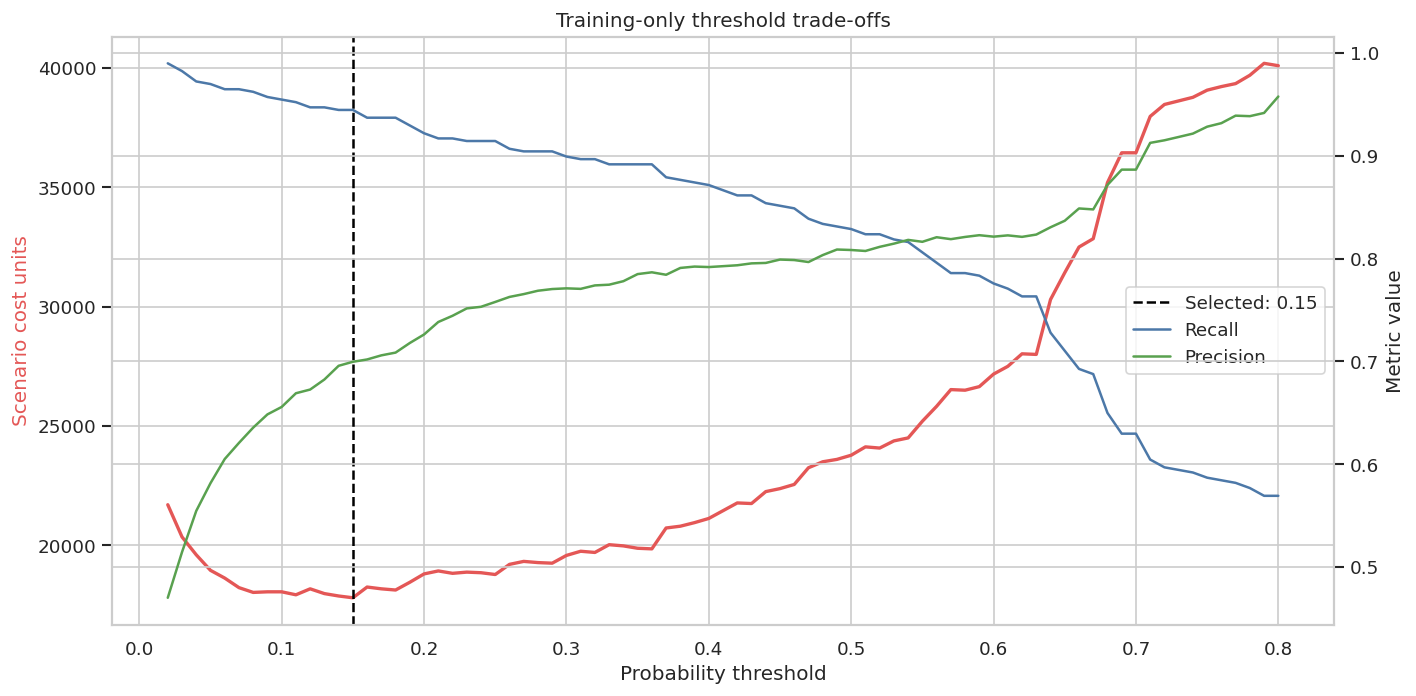

In [12]:
def threshold_metrics(target: pd.Series, probability: np.ndarray, threshold: float) -> dict[str, float]:
    prediction = (probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(target, prediction, labels=[0, 1]).ravel()
    contact_count = tp + fp
    cost_units = (
        CFG.contact_cost_units * contact_count
        + CFG.missed_churn_cost_units * fn
    )
    return {
        "threshold": float(threshold),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
        "precision": precision_score(target, prediction, zero_division=0),
        "recall": recall_score(target, prediction, zero_division=0),
        "f1": f1_score(target, prediction, zero_division=0),
        "balanced_accuracy": balanced_accuracy_score(target, prediction),
        "alert_rate": prediction.mean(),
        "cost_units": float(cost_units),
    }


threshold_table = pd.DataFrame([
    threshold_metrics(y_train, oof_calibrated_probability, threshold)
    for threshold in np.round(np.arange(0.02, 0.81, 0.01), 2)
])
no_intervention_cost = float(CFG.missed_churn_cost_units * y_train.sum())
threshold_table["cost_reduction_vs_no_intervention"] = no_intervention_cost - threshold_table["cost_units"]

best_threshold_row = threshold_table.sort_values(
    ["cost_units", "recall"], ascending=[True, False]
).iloc[0]
decision_threshold = float(best_threshold_row["threshold"])

display(threshold_table.sort_values("cost_units").head(12))
print(f"Selected threshold: {decision_threshold:.2f}")
print(f"Training-only scenario cost: {best_threshold_row['cost_units']:,.0f} units")
print(f"No-intervention scenario cost: {no_intervention_cost:,.0f} units")

fig, ax1 = plt.subplots(figsize=(12, 6))
ax1.plot(threshold_table["threshold"], threshold_table["cost_units"], color="#E45756", linewidth=2)
ax1.axvline(decision_threshold, color="black", linestyle="--", label=f"Selected: {decision_threshold:.2f}")
ax1.set_xlabel("Probability threshold")
ax1.set_ylabel("Scenario cost units", color="#E45756")
ax2 = ax1.twinx()
ax2.plot(threshold_table["threshold"], threshold_table["recall"], color="#4C78A8", label="Recall")
ax2.plot(threshold_table["threshold"], threshold_table["precision"], color="#59A14F", label="Precision")
ax2.set_ylabel("Metric value")
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2, loc="center right")
plt.title("Training-only threshold trade-offs")
plt.tight_layout()
threshold_chart_path = ARTIFACTS / "threshold_tradeoffs.png"
plt.savefig(threshold_chart_path, dpi=160, bbox_inches="tight")
plt.show()

## 11. Final holdout evaluation

The holdout is scored once after the algorithm, calibration approach and threshold have been fixed. Threshold-independent ranking metrics and threshold-dependent decision metrics are both reported.

              precision    recall  f1-score   support

    Retained      0.990     0.936     0.962       530
     Churned      0.732     0.949     0.827        98

    accuracy                          0.938       628
   macro avg      0.861     0.942     0.894       628
weighted avg      0.950     0.938     0.941       628



,operating_point,threshold,average_precision,roc_auc,precision,recall,f1,specificity,balanced_accuracy,accuracy,alert_rate,brier_score,log_loss,expected_calibration_error,true_negatives,false_positives,false_negatives,true_positives
0,Cost-selected threshold,0.1500,0.9550,0.9895,0.7323,0.9490,0.8267,0.9358,0.9424,0.9379,0.2022,0.0259,0.0918,0.0035,496,34,5,93
1,Default 0.50 threshold,0.5000,0.9550,0.9895,0.8980,0.8980,0.8980,0.9811,0.9395,0.9682,0.1561,0.0259,0.0918,0.0035,520,10,10,88


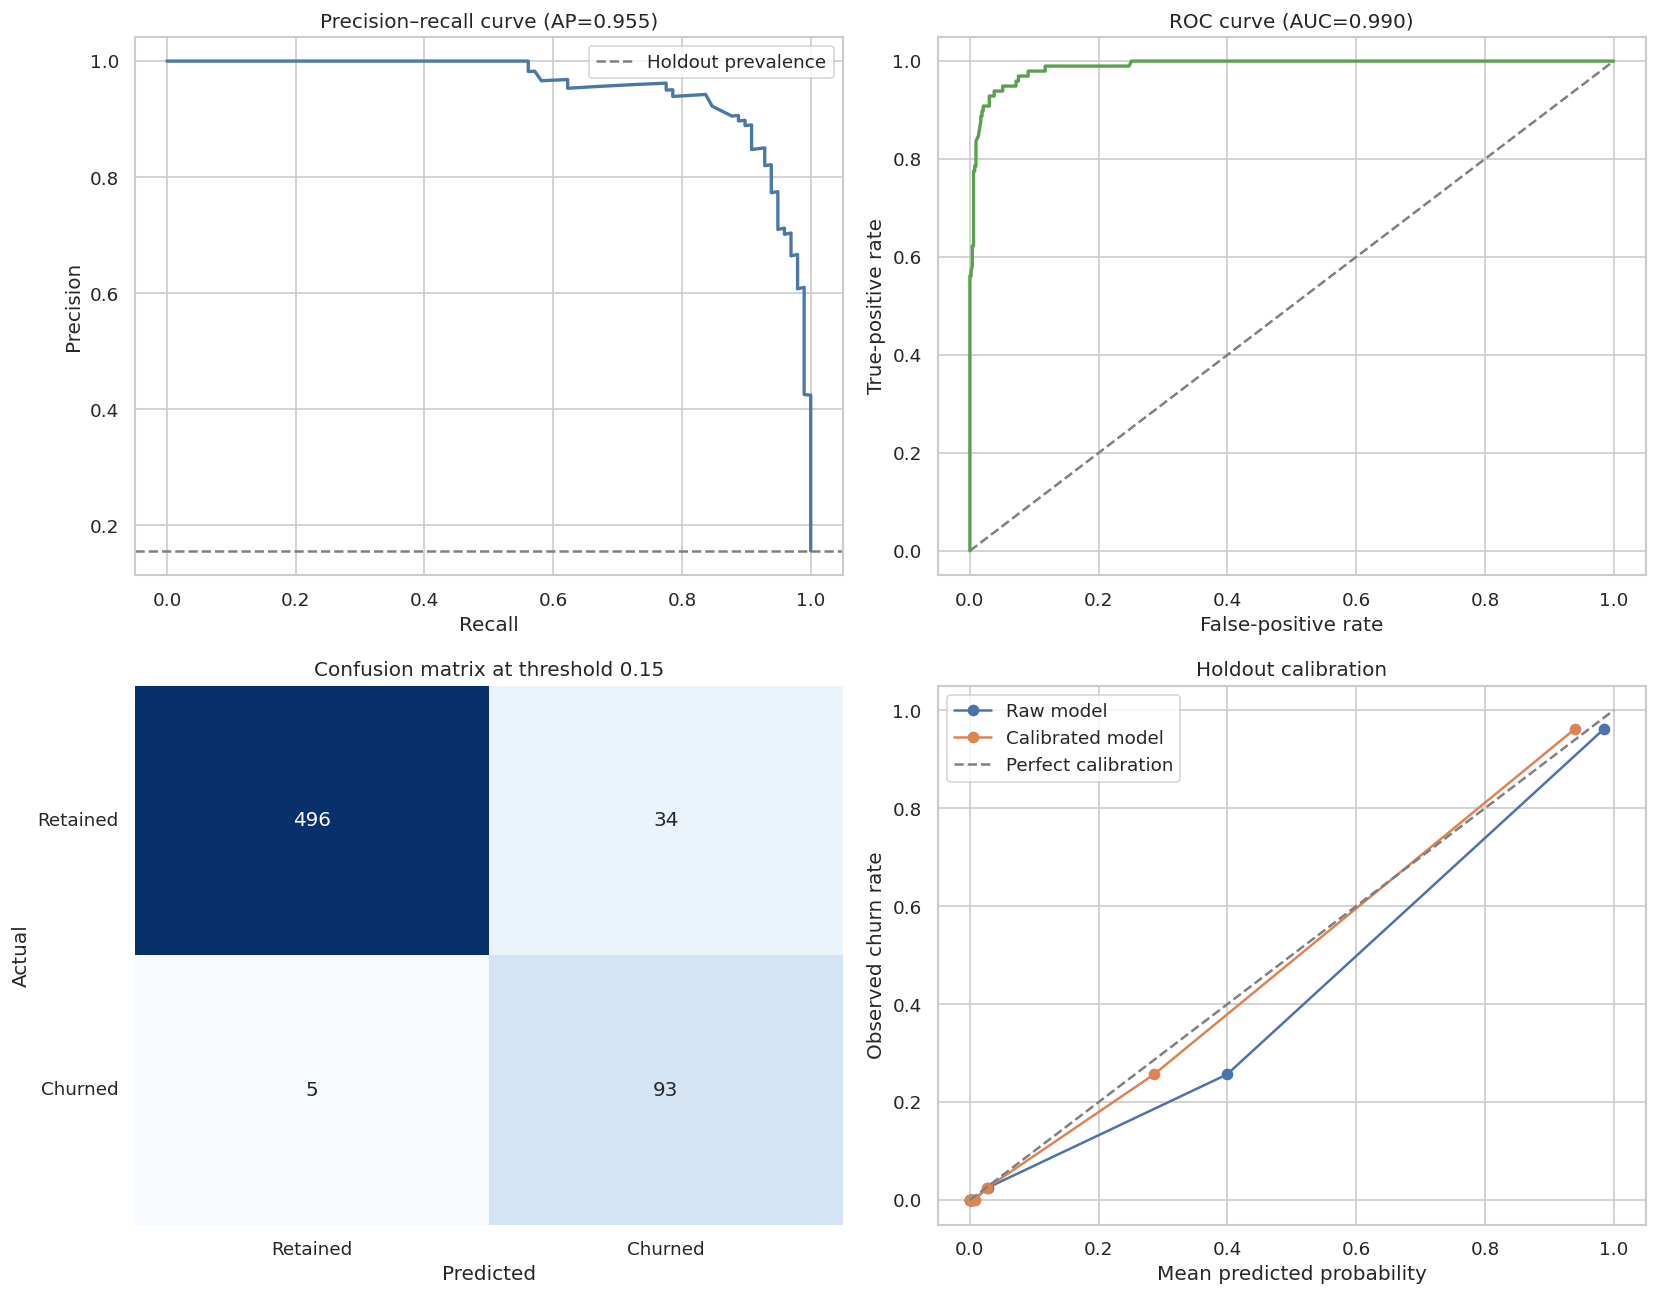

In [13]:
test_raw_probability = final_base_model.predict_proba(X_test)[:, 1]
test_probability = calibrated_model.predict_proba(X_test)[:, 1]
test_prediction = (test_probability >= decision_threshold).astype(int)
default_prediction = (test_probability >= 0.5).astype(int)


def expected_calibration_error(target: pd.Series, probability: np.ndarray, bins: int = 10) -> float:
    frame = pd.DataFrame({"target": np.asarray(target), "probability": probability})
    frame["bin"] = pd.qcut(frame["probability"], q=bins, duplicates="drop")
    grouped = frame.groupby("bin", observed=True).agg(
        rows=("target", "size"),
        observed_rate=("target", "mean"),
        mean_probability=("probability", "mean"),
    )
    return float(
        (grouped["rows"] / len(frame) * (grouped["observed_rate"] - grouped["mean_probability"]).abs()).sum()
    )


def evaluation_row(label: str, prediction: np.ndarray) -> dict[str, float]:
    tn, fp, fn, tp = confusion_matrix(y_test, prediction, labels=[0, 1]).ravel()
    return {
        "operating_point": label,
        "threshold": decision_threshold if label == "Cost-selected threshold" else 0.5,
        "average_precision": average_precision_score(y_test, test_probability),
        "roc_auc": roc_auc_score(y_test, test_probability),
        "precision": precision_score(y_test, prediction, zero_division=0),
        "recall": recall_score(y_test, prediction, zero_division=0),
        "f1": f1_score(y_test, prediction, zero_division=0),
        "specificity": tn / (tn + fp),
        "balanced_accuracy": balanced_accuracy_score(y_test, prediction),
        "accuracy": accuracy_score(y_test, prediction),
        "alert_rate": prediction.mean(),
        "brier_score": brier_score_loss(y_test, test_probability),
        "log_loss": log_loss(y_test, test_probability),
        "expected_calibration_error": expected_calibration_error(y_test, test_probability),
        "true_negatives": int(tn),
        "false_positives": int(fp),
        "false_negatives": int(fn),
        "true_positives": int(tp),
    }


test_metrics = pd.DataFrame([
    evaluation_row("Cost-selected threshold", test_prediction),
    evaluation_row("Default 0.50 threshold", default_prediction),
])
display(test_metrics)
print(classification_report(y_test, test_prediction, target_names=["Retained", "Churned"], digits=3))

precision_curve, recall_curve, _ = precision_recall_curve(y_test, test_probability)
false_positive_rate, true_positive_rate, _ = roc_curve(y_test, test_probability)
raw_observed, raw_predicted = calibration_curve(y_test, test_raw_probability, n_bins=8, strategy="quantile")
cal_observed, cal_predicted = calibration_curve(y_test, test_probability, n_bins=8, strategy="quantile")
holdout_confusion = confusion_matrix(y_test, test_prediction, labels=[0, 1])

fig, axes = plt.subplots(2, 2, figsize=(14, 11))
axes[0, 0].plot(recall_curve, precision_curve, color="#4C78A8", linewidth=2)
axes[0, 0].axhline(y_test.mean(), color="grey", linestyle="--", label="Holdout prevalence")
axes[0, 0].set_xlabel("Recall")
axes[0, 0].set_ylabel("Precision")
axes[0, 0].set_title(f"Precision–recall curve (AP={average_precision_score(y_test, test_probability):.3f})")
axes[0, 0].legend()
axes[0, 1].plot(false_positive_rate, true_positive_rate, color="#59A14F", linewidth=2)
axes[0, 1].plot([0, 1], [0, 1], color="grey", linestyle="--")
axes[0, 1].set_xlabel("False-positive rate")
axes[0, 1].set_ylabel("True-positive rate")
axes[0, 1].set_title(f"ROC curve (AUC={roc_auc_score(y_test, test_probability):.3f})")
sns.heatmap(holdout_confusion, annot=True, fmt="d", cmap="Blues", cbar=False, ax=axes[1, 0])
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("Actual")
axes[1, 0].set_xticklabels(["Retained", "Churned"])
axes[1, 0].set_yticklabels(["Retained", "Churned"], rotation=0)
axes[1, 0].set_title(f"Confusion matrix at threshold {decision_threshold:.2f}")
axes[1, 1].plot(raw_predicted, raw_observed, marker="o", label="Raw model")
axes[1, 1].plot(cal_predicted, cal_observed, marker="o", label="Calibrated model")
axes[1, 1].plot([0, 1], [0, 1], color="grey", linestyle="--", label="Perfect calibration")
axes[1, 1].set_xlabel("Mean predicted probability")
axes[1, 1].set_ylabel("Observed churn rate")
axes[1, 1].set_title("Holdout calibration")
axes[1, 1].legend()
plt.tight_layout()
evaluation_chart_path = ARTIFACTS / "holdout_evaluation.png"
plt.savefig(evaluation_chart_path, dpi=160, bbox_inches="tight")
plt.show()

## 12. Bootstrap uncertainty intervals

The holdout is modest, with fewer than 100 churners. Stratified bootstrap intervals show how uncertain the reported metrics are. They quantify sampling variation; they do not correct dataset shift or guarantee future performance.

In [14]:
rng = np.random.default_rng(SEED)
positive_indices = np.flatnonzero(y_test.to_numpy() == 1)
negative_indices = np.flatnonzero(y_test.to_numpy() == 0)
bootstrap_rows = []

for repetition in range(CFG.bootstrap_repetitions):
    sample_indices = np.concatenate([
        rng.choice(positive_indices, size=len(positive_indices), replace=True),
        rng.choice(negative_indices, size=len(negative_indices), replace=True),
    ])
    rng.shuffle(sample_indices)
    sampled_target = y_test.to_numpy()[sample_indices]
    sampled_probability = test_probability[sample_indices]
    sampled_prediction = (sampled_probability >= decision_threshold).astype(int)
    bootstrap_rows.append({
        "average_precision": average_precision_score(sampled_target, sampled_probability),
        "roc_auc": roc_auc_score(sampled_target, sampled_probability),
        "recall": recall_score(sampled_target, sampled_prediction, zero_division=0),
        "precision": precision_score(sampled_target, sampled_prediction, zero_division=0),
        "brier_score": brier_score_loss(sampled_target, sampled_probability),
    })

bootstrap_results = pd.DataFrame(bootstrap_rows)
point_metrics = test_metrics.set_index("operating_point").loc["Cost-selected threshold"]
bootstrap_intervals = pd.DataFrame([
    {
        "metric": metric,
        "point_estimate": float(point_metrics[metric]),
        "lower_95_pct": bootstrap_results[metric].quantile(0.025),
        "upper_95_pct": bootstrap_results[metric].quantile(0.975),
    }
    for metric in ["average_precision", "roc_auc", "recall", "precision", "brier_score"]
])
display(bootstrap_intervals)

,metric,point_estimate,lower_95_pct,upper_95_pct
0,average_precision,0.9550,0.9265,0.9800
1,roc_auc,0.9895,0.9816,0.9957
2,recall,0.9490,0.8980,0.9898
3,precision,0.7323,0.6691,0.8017
4,brier_score,0.0259,0.0173,0.0351


## 13. Predictive feature importance

Permutation importance measures the decrease in holdout average precision when one engineered feature is shuffled. It describes model reliance, not causality or a recommended intervention.

,feature,mean_ap_decrease,sd_ap_decrease
1,complains,0.1806,0.0274
4,seconds_of_use,0.0803,0.0174
2,subscription_length,0.0674,0.0136
3,charge_amount,0.0410,0.0110
5,frequency_of_use,0.0405,0.0097
15,usage_per_month,0.0392,0.0061
9,customer_value,0.0351,0.0110
10,call_failure_rate,0.0289,0.0089
11,seconds_per_call,0.0273,0.0060
0,call_failure,0.0090,0.0023


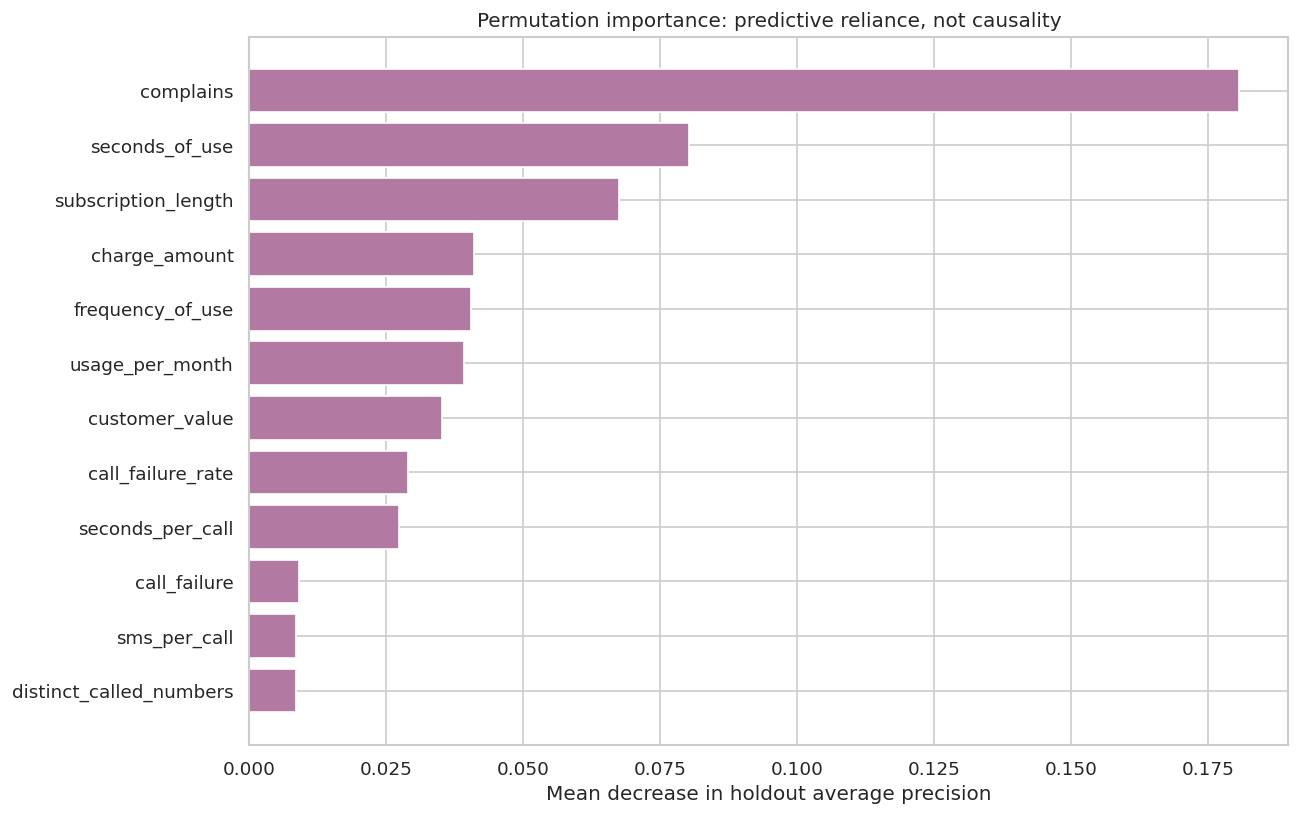

In [15]:
baseline_holdout_ap = average_precision_score(y_test, test_probability)
importance_rng = np.random.default_rng(SEED + 1)
importance_rows = []

for feature in X_test.columns:
    losses = []
    for _ in range(CFG.permutation_repetitions):
        permuted = X_test.copy()
        permuted[feature] = importance_rng.permutation(permuted[feature].to_numpy())
        permuted_probability = calibrated_model.predict_proba(permuted)[:, 1]
        losses.append(baseline_holdout_ap - average_precision_score(y_test, permuted_probability))
    importance_rows.append({
        "feature": feature,
        "mean_ap_decrease": float(np.mean(losses)),
        "sd_ap_decrease": float(np.std(losses, ddof=1)),
    })

feature_importance = pd.DataFrame(importance_rows).sort_values("mean_ap_decrease", ascending=False)
display(feature_importance.head(15))

plt.figure(figsize=(11, 7))
importance_plot = feature_importance.head(12).sort_values("mean_ap_decrease")
plt.barh(importance_plot["feature"], importance_plot["mean_ap_decrease"], color="#B279A2")
plt.xlabel("Mean decrease in holdout average precision")
plt.title("Permutation importance: predictive reliance, not causality")
plt.tight_layout()
importance_chart_path = ARTIFACTS / "feature_importance.png"
plt.savefig(importance_chart_path, dpi=160, bbox_inches="tight")
plt.show()

## 14. Subgroup performance review

Age is excluded from the model but retained for monitoring. Complaint and tariff-plan slices are also reported. Small slices are labelled; the notebook does not claim fairness from one dataset or equal metrics by chance.

,slice,value,rows,churners,observed_churn_rate,mean_predicted_probability,alert_rate,recall,false_positive_rate,precision,roc_auc,small_slice_warning
0,age_group,1,14,0,0.0000,0.0134,0.0000,NaN,0.0000,NaN,NaN,True
1,age_group,2,209,30,0.1435,0.1587,0.2105,1.0000,0.0782,0.6818,0.9889,False
2,age_group,3,289,47,0.1626,0.1629,0.1972,0.9574,0.0496,0.7895,0.9958,False
3,age_group,4,77,21,0.2727,0.2242,0.2857,0.8571,0.0714,0.8182,0.9677,False
4,age_group,5,39,0,0.0000,0.0519,0.1026,NaN,0.1026,0.0000,NaN,True
5,tariff_plan,1,591,97,0.1641,0.1680,0.2132,0.9485,0.0688,0.7302,0.9892,False
6,tariff_plan,2,37,1,0.0270,0.0108,0.0270,1.0000,0.0000,1.0000,1.0000,True
7,complains,0,575,54,0.0939,0.0993,0.1443,0.9074,0.0653,0.5904,0.9817,False
8,complains,1,53,44,0.8302,0.8036,0.8302,1.0000,0.0000,1.0000,1.0000,False


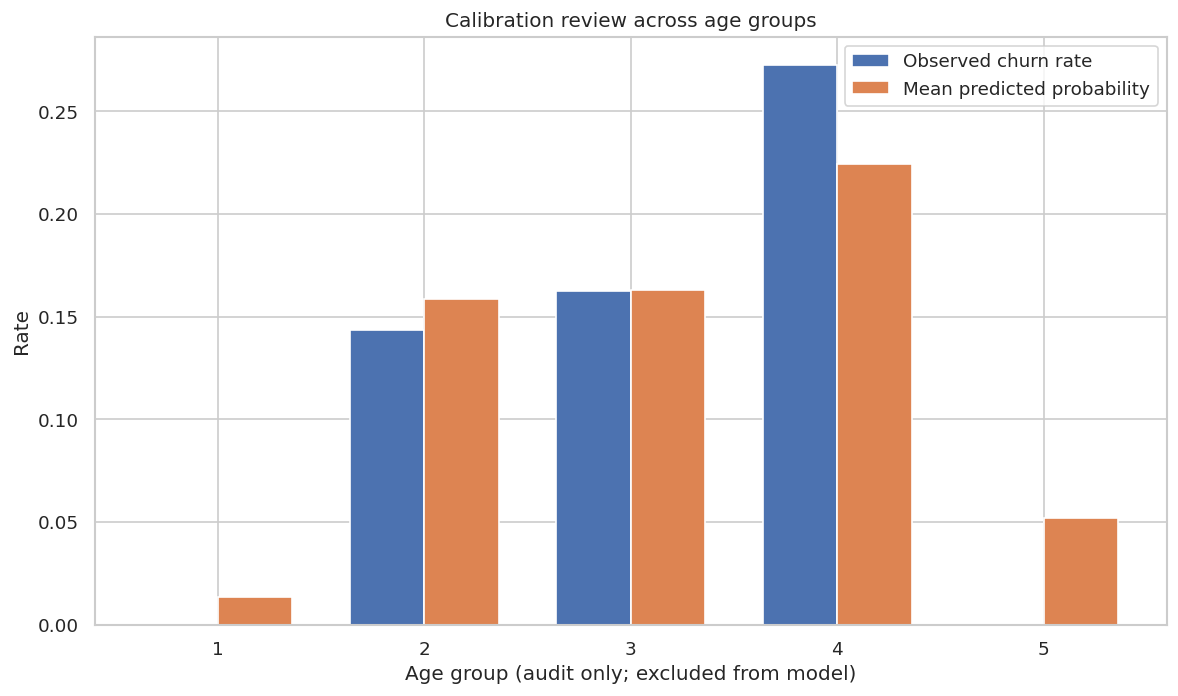

In [16]:
def safe_ratio(numerator: float, denominator: float) -> float:
    return float(numerator / denominator) if denominator else np.nan


slice_rows = []
for slice_name in ["age_group", "tariff_plan", "complains"]:
    values = raw_test[slice_name].to_numpy()
    for value in sorted(pd.unique(values)):
        mask = values == value
        target_slice = y_test.to_numpy()[mask]
        probability_slice = test_probability[mask]
        prediction_slice = test_prediction[mask]
        tn, fp, fn, tp = confusion_matrix(target_slice, prediction_slice, labels=[0, 1]).ravel()
        slice_rows.append({
            "slice": slice_name,
            "value": int(value),
            "rows": int(mask.sum()),
            "churners": int(target_slice.sum()),
            "observed_churn_rate": target_slice.mean(),
            "mean_predicted_probability": probability_slice.mean(),
            "alert_rate": prediction_slice.mean(),
            "recall": safe_ratio(tp, tp + fn),
            "false_positive_rate": safe_ratio(fp, fp + tn),
            "precision": safe_ratio(tp, tp + fp),
            "roc_auc": roc_auc_score(target_slice, probability_slice) if len(np.unique(target_slice)) == 2 else np.nan,
            "small_slice_warning": bool(mask.sum() < 50 or target_slice.sum() < 10),
        })

subgroup_metrics = pd.DataFrame(slice_rows)
display(subgroup_metrics)

age_audit = subgroup_metrics.loc[subgroup_metrics["slice"].eq("age_group")]
plt.figure(figsize=(10, 6))
positions = np.arange(len(age_audit))
width = 0.36
plt.bar(positions - width / 2, age_audit["observed_churn_rate"], width, label="Observed churn rate")
plt.bar(positions + width / 2, age_audit["mean_predicted_probability"], width, label="Mean predicted probability")
plt.xticks(positions, age_audit["value"])
plt.xlabel("Age group (audit only; excluded from model)")
plt.ylabel("Rate")
plt.title("Calibration review across age groups")
plt.legend()
plt.tight_layout()
subgroup_chart_path = ARTIFACTS / "age_group_audit.png"
plt.savefig(subgroup_chart_path, dpi=160, bbox_inches="tight")
plt.show()

## 15. Failure and uncertainty analysis

False positives consume retention capacity; false negatives are missed opportunities. The analysis preserves both error types and isolates scores close to the decision boundary for human review.

In [17]:
test_predictions = pd.DataFrame({
    "actual_churn": y_test,
    "churn_probability": test_probability,
    "flag_for_review": test_prediction,
})
test_predictions["error_type"] = np.select(
    [
        (test_predictions["actual_churn"] == 1) & (test_predictions["flag_for_review"] == 1),
        (test_predictions["actual_churn"] == 0) & (test_predictions["flag_for_review"] == 0),
        (test_predictions["actual_churn"] == 0) & (test_predictions["flag_for_review"] == 1),
        (test_predictions["actual_churn"] == 1) & (test_predictions["flag_for_review"] == 0),
    ],
    ["True positive", "True negative", "False positive", "False negative"],
    default="Unclassified",
)

failure_frame = pd.concat([
    test_predictions,
    raw_test[["complains", "frequency_of_use", "frequency_of_sms", "call_failure", "customer_value"]],
], axis=1)
failure_summary = (
    failure_frame.groupby("error_type")
    .agg(
        rows=("actual_churn", "size"),
        mean_probability=("churn_probability", "mean"),
        complaint_rate=("complains", "mean"),
        median_usage=("frequency_of_use", "median"),
        median_sms=("frequency_of_sms", "median"),
        median_call_failures=("call_failure", "median"),
        median_customer_value=("customer_value", "median"),
    )
    .reset_index()
)

uncertainty_band = 0.03
near_boundary = np.abs(test_probability - decision_threshold) <= uncertainty_band
uncertainty_summary = {
    "probability_band": [max(0, decision_threshold - uncertainty_band), min(1, decision_threshold + uncertainty_band)],
    "customers_near_boundary": int(near_boundary.sum()),
    "share_near_boundary_pct": float(100 * near_boundary.mean()),
    "observed_churn_rate_near_boundary": float(y_test.to_numpy()[near_boundary].mean()) if near_boundary.any() else None,
}

display(failure_summary)
print(json.dumps(uncertainty_summary, indent=2))

{
  "probability_band": [
    0.12,
    0.18
  ],
  "customers_near_boundary": 14,
  "share_near_boundary_pct": 2.229299363057325,
  "observed_churn_rate_near_boundary": 0.07142857142857142
}


,error_type,rows,mean_probability,complaint_rate,median_usage,median_sms,median_call_failures,median_customer_value
0,False negative,5,0.0810,0.0000,10.0000,1.0000,0.0000,36.3750
1,False positive,34,0.3862,0.0000,15.5000,9.0000,3.0000,91.6250
2,True negative,496,0.0115,0.0181,71.0000,31.5000,7.0000,359.7750
3,True positive,93,0.8653,0.4731,28.0000,11.0000,6.0000,94.5900


## 16. Drift reference and controlled monitor test

The dataset has no deployment-time batch, so the notebook does not fabricate “current drift.” It exports training reference statistics and a Population Stability Index function, then verifies the monitor with a deliberately shifted copy of one feature.

In [18]:
drift_reference = pd.DataFrame({
    "feature": X_train.columns,
    "mean": X_train.mean().values,
    "std": X_train.std().values,
    "minimum": X_train.min().values,
    "p05": X_train.quantile(0.05).values,
    "median": X_train.median().values,
    "p95": X_train.quantile(0.95).values,
    "maximum": X_train.max().values,
})


def population_stability_index(reference: pd.Series, current: pd.Series, bins: int = 10) -> float:
    reference_values = np.asarray(reference, dtype=float)
    current_values = np.asarray(current, dtype=float)
    edges = np.unique(np.quantile(reference_values, np.linspace(0, 1, bins + 1)))
    if len(edges) < 3:
        return 0.0
    edges[0], edges[-1] = -np.inf, np.inf
    reference_counts, _ = np.histogram(reference_values, bins=edges)
    current_counts, _ = np.histogram(current_values, bins=edges)
    reference_share = np.clip(reference_counts / reference_counts.sum(), 1e-6, None)
    current_share = np.clip(current_counts / current_counts.sum(), 1e-6, None)
    return float(np.sum((current_share - reference_share) * np.log(current_share / reference_share)))


controlled_shift = X_train["seconds_of_use"] * 1.5
controlled_shift_psi = population_stability_index(X_train["seconds_of_use"], controlled_shift)
assert controlled_shift_psi > 0.01
display(drift_reference)
print(f"Controlled seconds-of-use shift PSI: {controlled_shift_psi:.3f}")

Controlled seconds-of-use shift PSI: 0.159


,feature,mean,std,minimum,p05,median,p95,maximum
0,call_failure,7.4877,7.1911,0.0000,0.0000,6.0000,22.0000,36.0000
1,complains,0.0745,0.2627,0.0000,0.0000,0.0000,1.0000,1.0000
2,subscription_length,32.4691,8.5462,3.0000,13.0000,35.0000,42.0000,47.0000
3,charge_amount,0.9255,1.4957,0.0000,0.0000,0.0000,4.0000,10.0000
4,seconds_of_use,"4,409.4564","4,138.9316",0.0000,0.0000,"2,969.0000","14,894.5000","17,090.0000"
5,frequency_of_use,68.9175,56.9087,0.0000,0.0000,53.0000,182.0000,255.0000
6,frequency_of_sms,71.7280,111.0347,0.0000,0.0000,20.0000,347.9500,522.0000
7,distinct_called_numbers,23.3354,17.1954,0.0000,0.0000,21.0000,51.0000,97.0000
8,tariff_plan,1.0825,0.2751,1.0000,1.0000,1.0000,2.0000,2.0000
9,customer_value,462.5093,510.8766,0.0000,8.5963,225.5900,"1,558.1117","2,165.2800"


## 17. Validated inference path

The scoring function accepts only the ten operational inputs. It validates domains, recreates the fixed feature engineering and returns a calibrated probability plus a review recommendation. It does not use age or `Status`.

In [19]:
def validate_customer_input(record: dict[str, Any]) -> None:
    missing = sorted(set(MODEL_INPUT_COLUMNS) - set(record))
    if missing:
        raise ValueError(f"Missing required fields: {missing}")
    numeric_values = {field: float(record[field]) for field in MODEL_INPUT_COLUMNS}
    if any(value < 0 for value in numeric_values.values()):
        raise ValueError("Numeric inputs must be non-negative.")
    if int(record["complains"]) not in {0, 1}:
        raise ValueError("complains must be 0 or 1.")
    if int(record["tariff_plan"]) not in {1, 2}:
        raise ValueError("tariff_plan must be 1 or 2.")
    if not 0 <= float(record["charge_amount"]) <= 9:
        raise ValueError("charge_amount must be between 0 and 9.")
    if float(record["subscription_length"]) <= 0:
        raise ValueError("subscription_length must be positive.")


def predict_customer(record: dict[str, Any]) -> dict[str, Any]:
    validate_customer_input(record)
    raw_record = pd.DataFrame([{field: record[field] for field in MODEL_INPUT_COLUMNS}])
    engineered_record = engineer_features(raw_record, include_status=False)
    engineered_record = engineered_record.reindex(columns=X_train.columns)
    probability = float(calibrated_model.predict_proba(engineered_record)[0, 1])
    flagged = probability >= decision_threshold
    return {
        "calibrated_churn_probability": round(probability, 4),
        "decision_threshold": round(decision_threshold, 4),
        "flag_for_retention_review": bool(flagged),
        "recommended_action": "Prioritise for human retention review" if flagged else "No proactive review under current policy",
        "important_note": "Prediction is risk screening, not a causal explanation.",
    }


smoke_record = raw_train[MODEL_INPUT_COLUMNS].median(numeric_only=True).to_dict()
smoke_record["complains"] = int(smoke_record["complains"])
smoke_record["tariff_plan"] = int(smoke_record["tariff_plan"])
smoke_result = predict_customer(smoke_record)
assert 0 <= smoke_result["calibrated_churn_probability"] <= 1
assert isinstance(smoke_result["flag_for_retention_review"], bool)
print(json.dumps(smoke_result, indent=2))
print("Inference smoke test passed.")

{
  "calibrated_churn_probability": 0.1099,
  "decision_threshold": 0.15,
  "flag_for_retention_review": false,
  "recommended_action": "No proactive review under current policy",
  "important_note": "Prediction is risk screening, not a causal explanation."
}
Inference smoke test passed.


## 18. Optional interactive application

The interface is disabled by default so a full notebook run never blocks. Set `launch_app=True` in the configuration to launch it in Colab.

In [20]:
def score_from_form(
    call_failure: float,
    complains: int,
    subscription_length: float,
    charge_amount: float,
    seconds_of_use: float,
    frequency_of_use: float,
    frequency_of_sms: float,
    distinct_called_numbers: float,
    tariff_plan: int,
    customer_value: float,
) -> str:
    result = predict_customer({
        "call_failure": call_failure,
        "complains": complains,
        "subscription_length": subscription_length,
        "charge_amount": charge_amount,
        "seconds_of_use": seconds_of_use,
        "frequency_of_use": frequency_of_use,
        "frequency_of_sms": frequency_of_sms,
        "distinct_called_numbers": distinct_called_numbers,
        "tariff_plan": tariff_plan,
        "customer_value": customer_value,
    })
    return json.dumps(result, indent=2)


try:
    import gradio as gr

    with gr.Blocks(title="Customer Churn Prediction") as app:
        gr.Markdown("# Customer Churn Prediction\nCalibrated screening for retention review; not an automatic decision.")
        with gr.Row():
            call_failure_input = gr.Number(value=5, minimum=0, label="Call failures")
            complains_input = gr.Dropdown([0, 1], value=0, label="Complaint made")
            subscription_input = gr.Number(value=30, minimum=1, label="Subscription length")
            charge_input = gr.Number(value=1, minimum=0, maximum=9, label="Charge amount band")
            seconds_input = gr.Number(value=3000, minimum=0, label="Seconds of use")
        with gr.Row():
            calls_input = gr.Number(value=50, minimum=0, label="Frequency of use")
            sms_input = gr.Number(value=20, minimum=0, label="Frequency of SMS")
            distinct_input = gr.Number(value=20, minimum=0, label="Distinct called numbers")
            tariff_input = gr.Dropdown([1, 2], value=1, label="Tariff plan")
            value_input = gr.Number(value=250, minimum=0, label="Customer value")
        score_button = gr.Button("Score customer", variant="primary")
        result_output = gr.Code(label="Screening result", language="json")
        score_button.click(
            score_from_form,
            [
                call_failure_input, complains_input, subscription_input, charge_input, seconds_input,
                calls_input, sms_input, distinct_input, tariff_input, value_input,
            ],
            result_output,
        )

    if CFG.launch_app:
        app.launch(share=True, debug=False)
    else:
        print("Application built. Set launch_app=True in ProjectConfig to launch it.")
except Exception as exc:
    print(f"Optional Gradio interface unavailable: {type(exc).__name__}. Inference smoke test still passed.")

Optional Gradio interface unavailable: ImportError. Inference smoke test still passed.


## 19. Export reproducible artifacts and governance records

Generated data and artifact files are for runtime inspection. The GitHub repository needs only this notebook.

In [21]:
decision_metrics = test_metrics.set_index("operating_point").loc["Cost-selected threshold"].to_dict()

model_bundle = {
    "base_model": final_base_model,
    "probability_calibrator": probability_calibrator,
    "decision_threshold": decision_threshold,
    "engineered_feature_order": X_train.columns.tolist(),
    "raw_input_columns": MODEL_INPUT_COLUMNS,
    "excluded_fields": {
        "status": "semantic proxy-risk feature",
        "age": "not used for targeting; audit only",
        "age_group": "not used for targeting; audit only",
    },
    "decision_costs": {
        "contact_cost_units": CFG.contact_cost_units,
        "missed_churn_cost_units": CFG.missed_churn_cost_units,
    },
    "source_fingerprint": SOURCE_FINGERPRINT,
}

model_path = ARTIFACTS / "churn_model_bundle.joblib"
joblib.dump(model_bundle, model_path)

data_card = {
    "dataset": "UCI Iranian Churn",
    "source": SOURCE_FINGERPRINT,
    "rows": len(raw),
    "columns": raw.columns.tolist(),
    "target": "churn: 1 churned, 0 retained",
    "observed_churn_rate": float(y.mean()),
    "chronology": "features from first 9 months; churn at end of month 12; 3-month planning gap",
    "duplicate_profile_audit": DUPLICATE_AUDIT,
    "limitations": [
        "No customer identifier, so duplicate profiles cannot be resolved to individuals.",
        "No event timestamps, so a true calendar-time validation split is impossible.",
        "No intervention assignment or outcome, so uplift and causal retention effects cannot be estimated.",
        "Historical records from one Iranian telecom may not generalise to another market or period.",
    ],
}

model_card = {
    "model": selected_model_name,
    "purpose": "prioritise customers for human retention review",
    "primary_metric": "average precision",
    "selected_threshold": decision_threshold,
    "holdout_metrics": decision_metrics,
    "bootstrap_intervals": bootstrap_intervals.to_dict(orient="records"),
    "status_proxy_sensitivity": status_sensitivity.to_dict(orient="records"),
    "decision_costs": model_bundle["decision_costs"],
    "intended_use": "screening and workload prioritisation with human review",
    "prohibited_use": [
        "automatic denial, pricing or adverse treatment",
        "claims of causal churn drivers",
        "use in another population without validation and recalibration",
    ],
    "monitoring": [
        "input schema and ranges",
        "feature PSI and missingness",
        "calibration and churn prevalence",
        "recall, false-positive rate and alert volume by reviewed subgroup",
    ],
}

data_card_path = ARTIFACTS / "data_card.json"
model_card_path = ARTIFACTS / "model_card.json"
data_card_path.write_text(json.dumps(data_card, indent=2, default=str), encoding="utf-8")
model_card_path.write_text(json.dumps(model_card, indent=2, default=str), encoding="utf-8")

CSV_EXPORTS = {
    "quality_profile.csv": quality_profile,
    "split_profile.csv": split_profile,
    "cv_fold_results.csv": cv_results,
    "cv_summary.csv": cv_summary,
    "status_sensitivity.csv": status_sensitivity,
    "calibration_summary.csv": calibration_summary,
    "threshold_analysis.csv": threshold_table,
    "holdout_metrics.csv": test_metrics,
    "bootstrap_intervals.csv": bootstrap_intervals,
    "feature_importance.csv": feature_importance,
    "subgroup_metrics.csv": subgroup_metrics,
    "failure_summary.csv": failure_summary,
    "drift_reference.csv": drift_reference,
    "holdout_predictions.csv": test_predictions,
}
for filename, frame in CSV_EXPORTS.items():
    frame.to_csv(ARTIFACTS / filename, index=False)

ARTIFACT_PATHS = [
    model_path,
    data_card_path,
    model_card_path,
    *[ARTIFACTS / filename for filename in CSV_EXPORTS],
    eda_chart_path,
    model_comparison_chart_path,
    threshold_chart_path,
    evaluation_chart_path,
    importance_chart_path,
    subgroup_chart_path,
]

manifest_rows = []
for path in sorted(ARTIFACT_PATHS, key=lambda item: item.name):
    manifest_rows.append({
        "file": path.name,
        "bytes": path.stat().st_size,
        "sha256": sha256_file(path),
    })
artifact_manifest = pd.DataFrame(manifest_rows)
manifest_path = ARTIFACTS / "artifact_manifest.csv"
artifact_manifest.to_csv(manifest_path, index=False)
display(artifact_manifest)

,file,bytes,sha256
0,age_group_audit.png,55145,f8a75e03b92b45fe0f4fe5aa6f61d5b8eaffc79fcd66f3...
1,bootstrap_intervals.csv,393,a13a91a6374d362731befff02b6a0c4186779ee2c76815...
2,calibration_summary.csv,231,692ff82077e6c6e3c7adc189caf222bcbe70b6b01b3a18...
3,churn_model_bundle.joblib,570461,787d7a6a26c181df2611cc17fed0cee2e060824905adaf...
4,cv_fold_results.csv,2491,9c24de2f9653041358870ed52024c92fff2b6d4cce1c2d...
5,cv_summary.csv,704,cc4c39a404f6677ce05d28af4398330c671bc6e3d8d860...
6,data_card.json,1811,f25ee87775a2bcb4151c6e9df42d933d0c055d8772a859...
7,data_overview.png,117096,9908a30bbbf2fe68c31afaf22a35dfa09a2f9f829ea129...
8,drift_reference.csv,1542,9cdb0d212411df3e4269548f7e57601b87e6eca1c6a0d0...
9,failure_summary.csv,395,9b05fcf82527d9ecbe1294c92865870ba0195dbe9374bb...


## 20. Acceptance tests

The project fails loudly if core data, validation, model, decision or artifact assumptions are broken.

In [22]:
decision_row = test_metrics.set_index("operating_point").loc["Cost-selected threshold"]
default_row = test_metrics.set_index("operating_point").loc["Default 0.50 threshold"]

assert SOURCE_FINGERPRINT["matches_reference_archive"]
assert SOURCE_FINGERPRINT["matches_reference_csv"]
assert raw.shape == (3150, 14)
assert raw.isna().sum().sum() == 0
assert full_duplicate_rows == 300
assert mixed_label_profiles > 0
assert group_overlap == 0
assert set(X_train.columns) == set(X_test.columns)
assert not {"age", "age_group", "status"}.intersection(X_train.columns)
assert selected_model_name != "Prevalence baseline"
assert cv_summary.iloc[0]["mean_average_precision"] > y_train.mean() + 0.20
assert np.isfinite(oof_calibrated_probability).all()
assert ((oof_calibrated_probability >= 0) & (oof_calibrated_probability <= 1)).all()
assert 0 < decision_threshold < 1
assert threshold_table["cost_units"].min() < no_intervention_cost
assert test_probability.min() >= 0 and test_probability.max() <= 1
assert decision_row["average_precision"] > y_test.mean() + 0.20
assert decision_row["roc_auc"] > 0.80
assert decision_row["recall"] >= default_row["recall"]
assert decision_row["alert_rate"] < 0.50
assert bootstrap_intervals["lower_95_pct"].notna().all()
assert feature_importance["mean_ap_decrease"].notna().all()
assert len(subgroup_metrics) >= 9
assert controlled_shift_psi > 0.01
assert all(path.exists() and path.stat().st_size > 0 for path in ARTIFACT_PATHS)
assert artifact_manifest["sha256"].str.fullmatch(r"[0-9a-f]{64}").all()
assert manifest_path.exists() and manifest_path.stat().st_size > 0

reloaded_bundle = joblib.load(model_path)
assert math.isclose(reloaded_bundle["decision_threshold"], decision_threshold)
assert reloaded_bundle["engineered_feature_order"] == X_train.columns.tolist()

reloaded_raw_probability = reloaded_bundle["base_model"].predict_proba(X_test)[:, 1]
reloaded_probability = reloaded_bundle["probability_calibrator"].predict_proba(
    safe_logit(reloaded_raw_probability)
)[:, 1]
maximum_reload_delta = float(np.max(np.abs(reloaded_probability - test_probability)))
assert maximum_reload_delta < 1e-12
print(f"Maximum probability delta after reload: {maximum_reload_delta:.3g}")

print("ALL PROJECT 03 ACCEPTANCE TESTS PASSED")

Maximum probability delta after reload: 0
ALL PROJECT 03 ACCEPTANCE TESTS PASSED


## 21. Executive findings generated from the verified run

These statements are created from the current execution rather than typed in advance.

In [23]:
decision_row = test_metrics.set_index("operating_point").loc["Cost-selected threshold"]
top_feature = str(feature_importance.iloc[0]["feature"])

EXECUTIVE_FINDINGS = [
    f"The source contains {len(raw):,} customers with an observed churn rate of {100 * y.mean():.2f}%.",
    f"Grouped validation selected {selected_model_name}; duplicate predictor profiles never crossed the holdout boundary.",
    f"The status-excluded model achieved holdout average precision {decision_row['average_precision']:.3f} "
    f"and ROC-AUC {decision_row['roc_auc']:.3f}.",
    f"At the training-selected threshold of {decision_threshold:.2f}, holdout recall was "
    f"{100 * decision_row['recall']:.1f}% and precision was {100 * decision_row['precision']:.1f}%.",
    f"The policy flagged {100 * decision_row['alert_rate']:.1f}% of holdout customers for review.",
    f"The model relied most on {top_feature} by holdout permutation importance; this is predictive, not causal.",
    f"Including Status changed grouped-CV average precision by {status_ap_lift:+.3f}; it remained excluded because of proxy risk.",
]

for finding in EXECUTIVE_FINDINGS:
    print("•", finding)

• The source contains 3,150 customers with an observed churn rate of 15.71%.
• Grouped validation selected Histogram gradient boosting; duplicate predictor profiles never crossed the holdout boundary.
• The status-excluded model achieved holdout average precision 0.955 and ROC-AUC 0.990.
• At the training-selected threshold of 0.15, holdout recall was 94.9% and precision was 73.2%.
• The policy flagged 20.2% of holdout customers for review.
• The model relied most on complains by holdout permutation importance; this is predictive, not causal.
• Including Status changed grouped-CV average precision by +0.022; it remained excluded because of proxy risk.


## Interview explanation

**Problem:** Predict churn early enough for a retention team to act, while class imbalance and duplicate customer profiles can make headline accuracy misleading.

**Decision:** I used grouped stratified validation, selected by average precision, excluded age and a semantically risky `Status` proxy, calibrated out-of-fold probabilities and chose the threshold from explicit decision costs.

**Technical trade-off:** Excluding `Status` may sacrifice a small amount of predictive performance, but it makes the model easier to defend as an early-warning system instead of a restatement of whether someone is already inactive.

**Failure mode:** A random row split can place identical profiles in both train and test. That inflates performance, so identical predictor hashes are kept within one group throughout splitting and cross-validation.

**Next production step:** Validate on a later calendar cohort, estimate intervention uplift through a randomised retention experiment, replace cost assumptions with finance-approved values and monitor probability calibration, workload and subgroup error rates.

## CV bullet generated from verified metrics

Use this only after the acceptance tests pass.

In [24]:
cv_bullet = (
    f"Built a leakage-aware telecom churn screening system on {len(raw):,} real customer records, "
    f"using duplicate-profile grouped validation, calibrated {selected_model_name.lower()} and cost-based thresholding; "
    f"achieved {decision_row['average_precision']:.3f} holdout PR-AUC and "
    f"{100 * decision_row['recall']:.1f}% recall at {100 * decision_row['precision']:.1f}% precision, "
    f"with proxy-feature, subgroup and drift-monitoring checks."
)
print(cv_bullet)

Built a leakage-aware telecom churn screening system on 3,150 real customer records, using duplicate-profile grouped validation, calibrated histogram gradient boosting and cost-based thresholding; achieved 0.955 holdout PR-AUC and 94.9% recall at 73.2% precision, with proxy-feature, subgroup and drift-monitoring checks.


## Final checklist

- [x] Real, attributed public dataset with a three-month planning gap
- [x] Explicit data contract and duplicate-profile audit
- [x] Untouched grouped holdout and grouped cross-validation
- [x] Prevalence baseline plus interpretable and nonlinear models
- [x] Age excluded from targeting and `Status` proxy sensitivity tested
- [x] Out-of-fold probability calibration
- [x] Training-only cost-based threshold selection
- [x] PR-AUC, ROC-AUC, calibration, bootstrap intervals and failure analysis
- [x] Subgroup review, drift reference and validated inference path
- [x] Model/data cards, serialized bundle, tests and artifact manifest

**Portfolio rule:** upload this single notebook to the repository root. Do not upload the source data or generated artifact directory.

# Deeper exploratory analysis and retained evidence

These direct notebook cells extend the initial EDA with data-quality, scale, relationship, output and error diagnostics. They are intentionally visible here rather than hidden behind project helper functions.


In [ ]:
# Extended data-quality scorecard
if df is not None and len(df):
    quality_rows = []
    for col in df.columns:
        series = df[col]
        row = {
            'feature': col,
            'dtype': str(series.dtype),
            'rows': len(series),
            'missing': int(series.isna().sum()),
            'missing_pct': float(100 * series.isna().mean()),
            'unique': int(series.nunique(dropna=False)),
            'unique_pct': float(100 * series.nunique(dropna=False) / max(len(series), 1)),
        }
        if pd.api.types.is_numeric_dtype(series):
            values = pd.to_numeric(series, errors='coerce').dropna()
            if len(values):
                q1, q3 = values.quantile([0.25, 0.75])
                iqr = q3 - q1
                row.update({
                    'mean': float(values.mean()),
                    'median': float(values.median()),
                    'std': float(values.std()),
                    'p05': float(values.quantile(0.05)),
                    'p95': float(values.quantile(0.95)),
                    'skew': float(values.skew()),
                    'iqr_outliers': int(((values < q1 - 1.5*iqr) | (values > q3 + 1.5*iqr)).sum()),
                })
        quality_rows.append(row)
    deep_quality = pd.DataFrame(quality_rows)
    display(deep_quality.sort_values(['missing_pct','unique'], ascending=[False,False]).head(40))
    if 'iqr_outliers' in deep_quality:
        outlier_view = deep_quality.dropna(subset=['iqr_outliers']).sort_values('iqr_outliers', ascending=False).head(15)
        if len(outlier_view):
            plt.figure(figsize=(10,4))
            plt.bar(outlier_view['feature'], outlier_view['iqr_outliers'])
            plt.title('Potential IQR outliers by feature')
            plt.ylabel('Rows')
            plt.xticks(rotation=60, ha='right')
            plt.tight_layout()
            plt.show()
    card = deep_quality.sort_values('unique', ascending=False).head(20)
    plt.figure(figsize=(10,4))
    plt.bar(card['feature'], card['unique'])
    plt.title('Feature cardinality')
    plt.ylabel('Unique values')
    plt.xticks(rotation=60, ha='right')
    plt.tight_layout()
    plt.show()
    print('Constant columns:', deep_quality.loc[deep_quality['unique'] <= 1, 'feature'].tolist())
    print('High-missing columns:', deep_quality.loc[deep_quality['missing_pct'] >= 30, 'feature'].tolist())
    print('Possible identifier columns:', deep_quality.loc[deep_quality['unique_pct'] >= 95, 'feature'].tolist()[:20])
else:
    print('Materialise the documented dataset to run the extended data-quality scorecard.')


In [ ]:
# Numeric distributions, spread and strongest pairwise relationships
if df is not None and len(df):
    numeric_cols = df.select_dtypes(include=np.number).columns.tolist()[:12]
    for col in numeric_cols:
        values = pd.to_numeric(df[col], errors='coerce').dropna()
        if len(values) < 5:
            continue
        clipped = values.clip(values.quantile(0.01), values.quantile(0.99))
        plt.figure(figsize=(8,4))
        plt.hist(clipped, bins=35, alpha=0.82)
        plt.axvline(values.median(), linestyle='--', label=f'median={values.median():.3g}')
        plt.axvline(values.mean(), linestyle=':', label=f'mean={values.mean():.3g}')
        plt.title(f'Distribution: {col} (1st–99th percentile)')
        plt.xlabel(col)
        plt.ylabel('Rows')
        plt.legend()
        plt.tight_layout()
        plt.show()
        plt.figure(figsize=(8,3))
        plt.boxplot(values, vert=False, showfliers=True)
        plt.title(f'Spread / outliers: {col}')
        plt.xlabel(col)
        plt.tight_layout()
        plt.show()
    if len(numeric_cols) >= 2:
        corr = df[numeric_cols].corr(numeric_only=True)
        pairs = []
        for i, left in enumerate(corr.columns):
            for right in corr.columns[i+1:]:
                value = corr.loc[left, right]
                if pd.notna(value):
                    pairs.append({'feature_a': left, 'feature_b': right, 'correlation': float(value), 'abs_correlation': float(abs(value))})
        corr_pairs = pd.DataFrame(pairs).sort_values('abs_correlation', ascending=False) if pairs else pd.DataFrame()
        if len(corr_pairs):
            display(corr_pairs.head(20).round(4))
            for _, pair in corr_pairs.head(4).iterrows():
                sample = df[[pair['feature_a'], pair['feature_b']]].dropna()
                if len(sample) > 3000:
                    sample = sample.sample(3000, random_state=42)
                plt.figure(figsize=(7,5))
                plt.scatter(sample[pair['feature_a']], sample[pair['feature_b']], alpha=0.30, s=16)
                plt.xlabel(pair['feature_a'])
                plt.ylabel(pair['feature_b'])
                plt.title(f"{pair['feature_a']} vs {pair['feature_b']} (r={pair['correlation']:.2f})")
                plt.tight_layout()
                plt.show()
    categorical = [c for c in df.columns if 2 <= df[c].nunique(dropna=False) <= 20][:8]
    for col in categorical:
        counts = df[col].fillna('<missing>').astype(str).value_counts().head(20)
        shares = 100 * counts / counts.sum()
        display(pd.DataFrame({'rows': counts, 'share_pct': shares.round(2)}))
        plt.figure(figsize=(8,4))
        counts.sort_values().plot(kind='barh')
        plt.title(f'Category balance: {col}')
        plt.xlabel('Rows')
        plt.tight_layout()
        plt.show()
else:
    print('Materialise the documented dataset to run distribution diagnostics.')


In [ ]:
# Temporal coverage where date/time fields exist
if df is not None and len(df):
    time_cols = [c for c in df.columns if any(token in str(c).lower() for token in ('date','time','timestamp','datetime'))]
    print('Date/time candidates:', time_cols[:10])
    for col in time_cols[:4]:
        converted = pd.to_datetime(df[col], errors='coerce')
        valid = converted.dropna()
        if len(valid) >= max(10, int(0.25*len(df))):
            print(col, 'range:', valid.min(), '→', valid.max())
            monthly = valid.dt.to_period('M').value_counts().sort_index()
            if len(monthly) > 1:
                plt.figure(figsize=(10,4))
                plt.plot(monthly.index.astype(str), monthly.values, marker='o')
                plt.title(f'Rows over time: {col}')
                plt.ylabel('Rows')
                plt.xticks(rotation=70, ha='right')
                plt.tight_layout()
                plt.show()


## Retained outputs and error analysis

A strong portfolio keeps inspectable evidence. The cells below profile compact result tables and automatically detect prediction-like columns for residual or misclassification analysis.


In [ ]:
# Load compact result/evidence tables
result_tables = []
for base in [PROJECT/'results', PROJECT/'outputs', PROJECT/'artifacts', ROOT/'verified'/PROJECT_SLUG]:
    if not base.exists():
        continue
    for path in sorted(base.rglob('*')):
        if path.is_file() and path.suffix.lower() in {'.csv','.tsv','.parquet'} and path.stat().st_size < 25_000_000:
            try:
                if path.suffix.lower() == '.parquet':
                    table = pd.read_parquet(path)
                else:
                    table = pd.read_csv(path, sep='	' if path.suffix.lower() == '.tsv' else ',')
            except Exception as exc:
                print('Could not read', path.name, '-', exc)
                continue
            result_tables.append((path, table))
            print('
RESULT TABLE:', path.relative_to(ROOT) if ROOT in path.parents else path)
            print('shape=', table.shape)
            display(table.head(15))
            numeric = table.select_dtypes(include=np.number).columns.tolist()[:12]
            if numeric:
                display(table[numeric].describe().T.round(4))
print('Inspectable result tables:', len(result_tables))


In [ ]:
# Automatic regression/classification-style error diagnostics
actual_tokens = ('actual','target','truth','y_true','observed','label')
pred_tokens = ('prediction','predicted','forecast','y_pred')
confidence_tokens = ('confidence','probability','proba','risk','uncertainty')
for path, table in result_tables:
    actual_cols = [c for c in table.columns if any(token in str(c).lower() for token in actual_tokens)]
    pred_cols = [c for c in table.columns if any(token in str(c).lower() for token in pred_tokens)]
    conf_cols = [c for c in table.columns if any(token in str(c).lower() for token in confidence_tokens)]
    if actual_cols and pred_cols and len(table):
        actual_col = actual_cols[0]
        pred_col = next((c for c in pred_cols if c != actual_col), pred_cols[0])
        actual_num = pd.to_numeric(table[actual_col], errors='coerce')
        pred_num = pd.to_numeric(table[pred_col], errors='coerce')
        numeric_mask = actual_num.notna() & pred_num.notna()
        if numeric_mask.sum() >= 10:
            residual = actual_num[numeric_mask] - pred_num[numeric_mask]
            abs_error = residual.abs()
            print('
', path.name, '| MAE=', round(float(abs_error.mean()),5), '| RMSE=', round(float(np.sqrt(np.mean(residual**2))),5), '| bias=', round(float(residual.mean()),5))
            plt.figure(figsize=(7,5))
            plt.scatter(actual_num[numeric_mask], pred_num[numeric_mask], alpha=0.35, s=18)
            lo = min(actual_num[numeric_mask].min(), pred_num[numeric_mask].min())
            hi = max(actual_num[numeric_mask].max(), pred_num[numeric_mask].max())
            plt.plot([lo,hi],[lo,hi], linestyle='--')
            plt.xlabel(str(actual_col))
            plt.ylabel(str(pred_col))
            plt.title(f'Actual vs predicted — {path.name}')
            plt.tight_layout()
            plt.show()
            plt.figure(figsize=(7,4))
            plt.hist(residual, bins=30, alpha=0.82)
            plt.axvline(0, linestyle='--')
            plt.title(f'Residual distribution — {path.name}')
            plt.tight_layout()
            plt.show()
            worst_idx = abs_error.nlargest(min(15,len(abs_error))).index
            cols = list(dict.fromkeys([actual_col,pred_col]+conf_cols[:2]))
            worst = table.loc[worst_idx, cols].copy()
            worst['absolute_error'] = abs_error.loc[worst_idx].values
            display(worst.sort_values('absolute_error', ascending=False))
        else:
            agreement = table[actual_col].astype(str) == table[pred_col].astype(str)
            print('
', path.name, '| classification agreement=', round(float(agreement.mean()),4))
            if (~agreement).any():
                display(table.loc[~agreement, [actual_col,pred_col]+conf_cols[:2]].head(20))
    elif conf_cols:
        for col in conf_cols[:2]:
            values = pd.to_numeric(table[col], errors='coerce').dropna()
            if len(values) >= 10:
                plt.figure(figsize=(7,4))
                plt.hist(values, bins=30, alpha=0.82)
                plt.title(f'{col} distribution — {path.name}')
                plt.tight_layout()
                plt.show()


In [ ]:
# Display retained visual evidence from actual project runs
png_files = []
for base in [PROJECT/'results', PROJECT/'outputs', PROJECT/'artifacts', ROOT/'verified'/PROJECT_SLUG]:
    if base.exists():
        png_files.extend(sorted(base.rglob('*.png')))
print('Retained PNG figures:', len(png_files))
for path in png_files[:12]:
    try:
        image = plt.imread(path)
        plt.figure(figsize=(10,6))
        plt.imshow(image)
        plt.axis('off')
        plt.title(str(path.relative_to(ROOT)) if ROOT in path.parents else path.name)
        plt.tight_layout()
        plt.show()
    except Exception as exc:
        print('Could not display', path.name, '-', exc)


In [ ]:
# Reproducibility and evidence checklist
checks = [
    {'check':'README present', 'status':(PROJECT/'README.md').exists()},
    {'check':'Recruiter notebook present', 'status':(PROJECT/'project_notebook.ipynb').exists()},
    {'check':'Python implementation present', 'status':any(PROJECT.rglob('*.py'))},
    {'check':'Tests present', 'status':(PROJECT/'tests').exists() and any((PROJECT/'tests').rglob('test*.py'))},
    {'check':'Result/evidence files present', 'status':bool(candidate_files)},
    {'check':'Machine-readable JSON evidence', 'status':bool(json_files)},
    {'check':'Retained visual evidence', 'status':bool(png_files)},
]
checklist = pd.DataFrame(checks)
display(checklist)
print('Evidence checklist pass rate:', f"{100*checklist['status'].mean():.1f}%")
print('A failed item is a prompt to strengthen the project, not something to hide.')


# Engineering appendix — canonical application source

The analysis and visual evidence come first. The cells below preserve additional canonical Python from this project for reviewers who want to inspect pipelines, APIs, tests, feature code, monitoring and reusable implementation details.


## Canonical source: `run.py`


In [ ]:
from __future__ import annotations

import argparse
import json
from pathlib import Path

import numpy as np

from src.evaluation import operating_point, select_cost_threshold

ROOT = Path(__file__).resolve().parent
EVIDENCE = ROOT / "results" / "verified_metrics.json"


def self_test() -> None:
    y = np.array([0, 0, 0, 1, 1])
    probability = np.array([0.05, 0.10, 0.30, 0.70, 0.90])
    metrics = operating_point(y, probability, 0.50)
    assert metrics["precision"] == 1.0
    assert metrics["recall"] == 1.0
    assert metrics["alert_rate"] == 0.4
    selected = select_cost_threshold(y, probability)
    assert 0.01 <= selected["threshold"] <= 0.99
    assert selected["cost_units"] >= 0
    print("Customer churn self-test passed.")


def check_evidence() -> None:
    report = json.loads(EVIDENCE.read_text(encoding="utf-8"))
    assert report["verification_pass"] is True
    assert report["source_rows"] == 3150
    assert report["training_rows"] == 2522
    assert report["holdout_rows"] == 628
    assert report["training_profiles"] == 2229
    assert report["holdout_profiles"] == 565
    assert report["selected_algorithm"] == "Histogram gradient boosting"
    assert report["training_selected_threshold"] == 0.15
    assert report["holdout_metrics"]["average_precision"] == 0.955
    assert report["holdout_metrics"]["recall"] == 0.949
    assert report["holdout_metrics"]["precision"] == 0.7323
    assert report["holdout_metrics"]["alert_rate"] == 0.2022
    assert report["excluded_fields"]["status"].startswith("semantic proxy-risk")
    print("Retained churn evidence passed.")


def main() -> int:
    parser = argparse.ArgumentParser()
    parser.add_argument("--self-test", action="store_true")
    parser.add_argument("--check-evidence", action="store_true")
    args = parser.parse_args()
    if args.self_test:
        self_test()
    if args.check_evidence:
        check_evidence()
    if not args.self_test and not args.check_evidence:
        parser.error("choose --self-test or --check-evidence")
    return 0


if __name__ == "__main__":
    raise SystemExit(main())


## Canonical source: `src/__init__.py`


In [ ]:
"""Leakage-aware customer churn screening package."""


## Canonical source: `src/data.py`


In [ ]:
from __future__ import annotations

import hashlib
import re
import urllib.request
import zipfile
from pathlib import Path

import pandas as pd
from sklearn.model_selection import StratifiedGroupKFold

DATASET_URL = "https://archive.ics.uci.edu/static/public/563/iranian+churn+dataset.zip"
ARCHIVE_SHA256 = "696c3a1812267980751f30d19193a1b430ac4ad76172bb089e664c96813ead66"
CSV_SHA256 = "90d5fb6bd1630cd4de4b4d28fcf8b4cb92a8f6ab7484605b0799d47386f7dbe1"
CSV_NAME = "Customer Churn.csv"
SEED = 42

OPERATIONAL_INPUT_COLUMNS = [
    "call_failure",
    "complains",
    "subscription_length",
    "charge_amount",
    "seconds_of_use",
    "frequency_of_use",
    "frequency_of_sms",
    "distinct_called_numbers",
    "tariff_plan",
    "customer_value",
]
EXCLUDED_FIELDS = {
    "status": "semantic proxy-risk feature; sensitivity analysis only",
    "age": "subgroup monitoring only",
    "age_group": "subgroup monitoring only",
}


def sha256_file(path: Path) -> str:
    digest = hashlib.sha256()
    with path.open("rb") as handle:
        for chunk in iter(lambda: handle.read(1 << 20), b""):
            digest.update(chunk)
    return digest.hexdigest()


def _snake_case(value: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", value.strip().lower()).strip("_")


def download_dataset(cache_dir: Path) -> Path:
    """Download the pinned UCI source and refuse silent source changes."""
    cache_dir.mkdir(parents=True, exist_ok=True)
    archive_path = cache_dir / "iranian_churn_dataset.zip"
    csv_path = cache_dir / CSV_NAME

    if not archive_path.exists():
        request = urllib.request.Request(DATASET_URL, headers={"User-Agent": "Mozilla/5.0"})
        with urllib.request.urlopen(request, timeout=120) as response, archive_path.open("wb") as target:
            for chunk in iter(lambda: response.read(1 << 20), b""):
                target.write(chunk)

    if sha256_file(archive_path) != ARCHIVE_SHA256:
        raise ValueError("UCI archive SHA-256 does not match the pinned project source")

    with zipfile.ZipFile(archive_path) as archive:
        if CSV_NAME not in archive.namelist():
            raise ValueError(f"{CSV_NAME!r} is missing from the UCI archive")
        archive.extract(CSV_NAME, cache_dir)

    if sha256_file(csv_path) != CSV_SHA256:
        raise ValueError("extracted churn CSV SHA-256 does not match the pinned project source")
    return csv_path


def load_dataset(csv_path: Path) -> pd.DataFrame:
    frame = pd.read_csv(csv_path)
    frame.columns = [_snake_case(column) for column in frame.columns]
    required = set(OPERATIONAL_INPUT_COLUMNS) | {"churn", "status", "age", "age_group"}
    missing = sorted(required - set(frame.columns))
    if missing:
        raise ValueError(f"source schema is missing expected columns: {missing}")
    if len(frame) != 3150:
        raise ValueError(f"expected 3,150 source rows, found {len(frame):,}")
    if frame[list(required)].isna().any().any():
        raise ValueError("unexpected missing values in the pinned modelling fields")
    return frame


def operational_profile_groups(frame: pd.DataFrame) -> pd.Series:
    """Stable group IDs so identical predictor profiles cannot cross a split."""
    return pd.util.hash_pandas_object(frame[OPERATIONAL_INPUT_COLUMNS], index=False).astype(str)


def protected_holdout_split(frame: pd.DataFrame):
    """Replicate the notebook's 5-fold grouped, stratified protected holdout."""
    X = frame[OPERATIONAL_INPUT_COLUMNS].copy()
    y = frame["churn"].astype(int).copy()
    groups = operational_profile_groups(frame)
    splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    train_index, test_index = next(splitter.split(X, y, groups=groups))
    train = frame.iloc[train_index].reset_index(drop=True)
    holdout = frame.iloc[test_index].reset_index(drop=True)

    train_profiles = set(operational_profile_groups(train))
    holdout_profiles = set(operational_profile_groups(holdout))
    if train_profiles & holdout_profiles:
        raise AssertionError("identical predictor profiles crossed the holdout boundary")
    return train, holdout


## Canonical source: `src/evaluation.py`


In [ ]:
from __future__ import annotations

import numpy as np
from sklearn.metrics import (
    accuracy_score,
    average_precision_score,
    balanced_accuracy_score,
    brier_score_loss,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)

CONTACT_COST_UNITS = 25.0
MISSED_CHURN_COST_UNITS = 200.0


def operating_point(y_true, probability, threshold: float) -> dict[str, float]:
    y = np.asarray(y_true, dtype=int)
    p = np.asarray(probability, dtype=float)
    prediction = (p >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, prediction, labels=[0, 1]).ravel()
    return {
        "threshold": float(threshold),
        "average_precision": float(average_precision_score(y, p)),
        "roc_auc": float(roc_auc_score(y, p)),
        "precision": float(precision_score(y, prediction, zero_division=0)),
        "recall": float(recall_score(y, prediction, zero_division=0)),
        "f1": float(f1_score(y, prediction, zero_division=0)),
        "specificity": float(tn / (tn + fp)) if tn + fp else 0.0,
        "balanced_accuracy": float(balanced_accuracy_score(y, prediction)),
        "accuracy": float(accuracy_score(y, prediction)),
        "alert_rate": float(prediction.mean()),
        "brier_score": float(brier_score_loss(y, p)),
        "false_positives": int(fp),
        "false_negatives": int(fn),
    }


def scenario_cost(y_true, probability, threshold: float) -> float:
    metrics = operating_point(y_true, probability, threshold)
    return float(
        CONTACT_COST_UNITS * metrics["false_positives"]
        + MISSED_CHURN_COST_UNITS * metrics["false_negatives"]
    )


def select_cost_threshold(y_true, probability) -> dict[str, float]:
    """Choose an operating threshold from training-only probabilities."""
    p = np.asarray(probability, dtype=float)
    candidates = np.unique(np.r_[0.01, np.round(p, 4), 0.99])
    candidates = candidates[(candidates >= 0.01) & (candidates <= 0.99)]
    rows = []
    for threshold in candidates:
        metrics = operating_point(y_true, p, float(threshold))
        metrics["cost_units"] = scenario_cost(y_true, p, float(threshold))
        rows.append(metrics)
    rows.sort(key=lambda row: (row["cost_units"], -row["recall"], row["threshold"]))
    return rows[0]


## Canonical source: `src/features.py`


In [ ]:
from __future__ import annotations

import pandas as pd

from .data import OPERATIONAL_INPUT_COLUMNS

ENGINEERED_FEATURES = [
    "call_failure_rate",
    "seconds_per_call",
    "sms_per_call",
    "contact_diversity",
    "customer_value_per_month",
    "usage_per_month",
]
MODEL_FEATURES = OPERATIONAL_INPUT_COLUMNS + ENGINEERED_FEATURES


def engineer_features(frame: pd.DataFrame) -> pd.DataFrame:
    data = frame[OPERATIONAL_INPUT_COLUMNS].copy().astype(float)
    call_denominator = data["frequency_of_use"].clip(lower=0) + 1.0
    subscription_denominator = data["subscription_length"].clip(lower=1)
    data["call_failure_rate"] = data["call_failure"] / (
        data["call_failure"] + data["frequency_of_use"] + 1.0
    )
    data["seconds_per_call"] = data["seconds_of_use"] / call_denominator
    data["sms_per_call"] = data["frequency_of_sms"] / call_denominator
    data["contact_diversity"] = data["distinct_called_numbers"] / call_denominator
    data["customer_value_per_month"] = data["customer_value"] / subscription_denominator
    data["usage_per_month"] = data["frequency_of_use"] / subscription_denominator
    return data[MODEL_FEATURES]


## Canonical source: `src/model.py`


In [ ]:
from __future__ import annotations

import numpy as np
from scipy.special import expit, logit
from sklearn.base import clone
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold, cross_val_predict

from .features import engineer_features

SEED = 42


def build_model() -> HistGradientBoostingClassifier:
    return HistGradientBoostingClassifier(
        max_iter=300,
        learning_rate=0.05,
        max_leaf_nodes=15,
        min_samples_leaf=20,
        l2_regularization=1.0,
        class_weight="balanced",
        random_state=SEED,
    )


def safe_logit(probability) -> np.ndarray:
    p = np.clip(np.asarray(probability, dtype=float), 1e-6, 1 - 1e-6)
    return logit(p).reshape(-1, 1)


def fit_calibrated_model(raw_train, y_train, groups):
    """Fit calibration only on grouped out-of-fold training predictions."""
    X = engineer_features(raw_train)
    splitter = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=SEED)
    template = build_model()
    oof_raw = cross_val_predict(
        template,
        X,
        y_train,
        groups=groups,
        cv=splitter,
        method="predict_proba",
        n_jobs=1,
    )[:, 1]
    calibrator = LogisticRegression(C=1e6, max_iter=2000, random_state=SEED)
    calibrator.fit(safe_logit(oof_raw), y_train)
    base_model = clone(template).fit(X, y_train)
    return base_model, calibrator, oof_raw


def calibrated_probability(base_model, calibrator, raw_frame) -> np.ndarray:
    raw_probability = base_model.predict_proba(engineer_features(raw_frame))[:, 1]
    calibrated_logit = calibrator.decision_function(safe_logit(raw_probability))
    return expit(calibrated_logit)


## Canonical source: `tests/test_evaluation.py`


In [ ]:
import numpy as np

from src.evaluation import operating_point, scenario_cost, select_cost_threshold


def test_operating_point_reports_decision_metrics():
    y = np.array([0, 0, 1, 1])
    p = np.array([0.1, 0.4, 0.6, 0.9])
    metrics = operating_point(y, p, 0.5)
    assert metrics["precision"] == 1.0
    assert metrics["recall"] == 1.0
    assert metrics["specificity"] == 1.0
    assert metrics["alert_rate"] == 0.5


def test_missing_churn_costs_more_than_extra_review():
    y = np.array([0, 1])
    p = np.array([0.4, 0.4])
    conservative = scenario_cost(y, p, 0.5)
    review_both = scenario_cost(y, p, 0.3)
    assert review_both < conservative


def test_threshold_is_selected_from_training_probabilities():
    y = np.array([0, 0, 0, 1, 1, 1])
    p = np.array([0.02, 0.10, 0.35, 0.60, 0.75, 0.95])
    selected = select_cost_threshold(y, p)
    assert 0.01 <= selected["threshold"] <= 0.99
    assert selected["cost_units"] >= 0


# Portfolio depth check

**Meaningful code lines visible in this notebook:** 1,479. For a major recruiter-facing application the working target is roughly **1,000 meaningful lines**, with a practical guide of about 600–1,400 depending on the problem. This notebook is larger than the usual guide; keep the extra code only when it is genuinely project-specific.

Line count is not a quality metric by itself. Add code only when it improves the real project: data acquisition, validation, cleaning, EDA, visualisation, feature engineering, baselines, model comparison, tuning, leakage control, error analysis, explainability, uncertainty, inference, tests, monitoring, deployment or decision logic.
